Title: LEE_ERA5_Results_specific_event.ipynb

Purpose: Look at an exemplary event in the ERA5 data

Author: Onno Nennecke on 29.08.2025 Modified: 11.09.2025

Input data: 

- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'
- adjusted final model output
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'


Output data:

- Event TS Plots: Event_2017_TS, Event_2024_TS
    - These files lie here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import os
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib import gridspec
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from datetime import datetime, timedelta
import matplotlib.dates as mdates


### Read LEE data

In [2]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')


### Filter for ERA5 LEE data

In [3]:
# Remove all CMIP data from the LEE_dat DataFrame
LEE_dat_non_CMIP = LEE_dat[(LEE_dat['ESM'] == 'ERA5_week') | (LEE_dat['ESM'] == 'ERA5_wwd') | (LEE_dat['ESM'] == 'SMARD')]
LEE_7_non_CMIP = LEE_7[(LEE_7['ESM'] == 'ERA5_week') | (LEE_7['ESM'] == 'ERA5_wwd') | (LEE_7['ESM'] == 'SMARD')]
LEE_14_non_CMIP = LEE_14[(LEE_14['ESM'] == 'ERA5_week') | (LEE_14['ESM'] == 'ERA5_wwd') | (LEE_14['ESM'] == 'SMARD')]
LEE_vl_non_CMIP = LEE_vl[(LEE_vl['ESM'] == 'ERA5_week') | (LEE_vl['ESM'] == 'ERA5_wwd') | (LEE_vl['ESM'] == 'SMARD')]

# Pure ERA5 data
LEE_dat_ERA5 = LEE_dat[(LEE_dat['ESM'] == 'ERA5_week')]
LEE_7_ERA5 = LEE_7[(LEE_7['ESM'] == 'ERA5_week')]
LEE_14_ERA5 = LEE_14[(LEE_14['ESM'] == 'ERA5_week')]
LEE_vl_ERA5 = LEE_vl[(LEE_vl['ESM'] == 'ERA5_week')]

### Pick events

### Long event (1 week)

In [4]:
LEE_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-12-11,2015-12-17,2015-12-11 00:00:00.000000005,344,350,349,7,1537.778924,1404.602138,109.037426,9832.214968,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,345
1,2016-12-21,2016-12-27,2016-12-21 00:00:00.000000001,719,725,720,7,1502.845828,1448.824302,55.285408,10141.770116,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,355
2,2017-11-27,2017-12-03,2017-11-27 00:00:00.000000001,1060,1066,1061,7,1500.833281,1403.926578,75.104923,9827.486045,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,331
3,2017-12-01,2017-12-07,2017-12-01 00:00:00.000000005,1064,1070,1069,7,1483.982184,1420.771437,42.096442,9945.400059,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,335
4,2018-01-18,2018-01-24,2018-01-18 00:00:00.000000002,1112,1118,1114,7,1479.508737,1426.710531,69.408603,9986.973719,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2018,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,2023-01-24,2023-01-30,2023-01-24 00:00:00.000000002,2943,2949,2945,7,1493.480853,1407.710098,88.175757,9853.970686,1140,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,24
1140,2024-11-05,2024-11-11,2024-11-05 00:00:00.000000005,3593,3599,3598,7,1434.148158,1403.884956,24.601696,9827.194690,1141,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,309
1141,2024-11-10,2024-11-16,2024-11-10 00:00:00.000000006,3598,3604,3604,7,1468.658163,1407.040411,40.182743,9849.282876,1142,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,314
1142,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000001,18,24,19,7,1567.507000,1432.481214,160.806691,10027.368500,1143,SMARD,SMARD_hist,2015,19


In [5]:
LEE_7[(LEE_7['ESM'] == 'ERA5_week')]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
550,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000004,18,24,22,7,1497.249011,1449.366519,46.744941,10145.565631,551,ERA5_week,ERA5_hist_week,2015,19
551,2016-01-15,2016-01-21,2016-01-15 00:00:00.000000006,379,385,385,7,1502.737606,1456.367093,32.641307,10194.569654,552,ERA5_week,ERA5_hist_week,2016,15
552,2016-12-14,2016-12-20,2016-12-14 00:00:00.000000003,712,718,715,7,1458.652965,1415.033120,53.764337,9905.231838,553,ERA5_week,ERA5_hist_week,2016,348
553,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000004,748,754,752,7,1541.727728,1478.688488,49.626313,10350.819414,554,ERA5_week,ERA5_hist_week,2017,19
554,2019-01-19,2019-01-25,2019-01-19 00:00:00.000000005,1478,1484,1483,7,1542.347000,1450.622709,86.209183,10154.358961,555,ERA5_week,ERA5_hist_week,2019,19
555,2020-11-26,2020-12-02,2020-11-26 00:00:00.000000006,2154,2160,2160,7,1470.258197,1424.666513,40.762916,9972.665588,556,ERA5_week,ERA5_hist_week,2020,330
556,2022-12-10,2022-12-16,2022-12-10 00:00:00.000000006,2898,2904,2904,7,1554.145256,1492.080803,26.066980,10444.565622,557,ERA5_week,ERA5_hist_week,2022,344
557,2023-01-20,2023-01-26,2023-01-20 00:00:00.000000000,2939,2945,2939,7,1502.508759,1411.341731,74.062268,9879.392118,558,ERA5_week,ERA5_hist_week,2023,20
558,2023-01-22,2023-01-28,2023-01-22 00:00:00.000000006,2941,2947,2947,7,1460.861030,1418.133334,51.195259,9926.933336,559,ERA5_week,ERA5_hist_week,2023,22
559,2023-11-27,2023-12-03,2023-11-27 00:00:00.000000005,3250,3256,3255,7,1540.015423,1450.126204,77.766638,10150.883425,560,ERA5_week,ERA5_hist_week,2023,331


In [6]:
LEE_vl[(LEE_vl['ESM'] == 'ERA5_wwd')][140:150]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
5381,2024-01-17,2024-01-18,2024-01-17 00:00:00.000000000,3301,3302,3301,2,1466.278102,1460.218221,6.059880,2920.436443,5382,ERA5_wwd,ERA5_hist_wwd,2024,17
5382,2024-02-08,2024-02-08,2024-02-08 00:00:00.000000000,3323,3323,3323,1,1479.437341,1479.437341,0.000000,1479.437341,5383,ERA5_wwd,ERA5_hist_wwd,2024,39
5383,2024-02-27,2024-02-27,2024-02-27 00:00:00.000000000,3342,3342,3342,1,1425.230363,1425.230363,0.000000,1425.230363,5384,ERA5_wwd,ERA5_hist_wwd,2024,58
5384,2024-03-12,2024-03-12,2024-03-12 00:00:00.000000000,3355,3355,3355,1,1398.526241,1398.526241,0.000000,1398.526241,5385,ERA5_wwd,ERA5_hist_wwd,2024,71
5385,2024-11-04,2024-11-07,2024-11-04 00:00:00.000000003,3592,3595,3595,4,1504.718685,1477.291484,24.737551,5909.165937,5386,ERA5_wwd,ERA5_hist_wwd,2024,308
5386,2024-11-11,2024-11-13,2024-11-11 00:00:00.000000001,3599,3601,3600,3,1470.530233,1458.748136,9.610479,4376.244409,5387,ERA5_wwd,ERA5_hist_wwd,2024,315
5387,2024-11-29,2024-11-29,2024-11-29 00:00:00.000000000,3617,3617,3617,1,1508.149164,1508.149164,0.000000,1508.149164,5388,ERA5_wwd,ERA5_hist_wwd,2024,333
5388,2024-12-04,2024-12-04,2024-12-04 00:00:00.000000000,3622,3622,3622,1,1481.906900,1481.906900,0.000000,1481.906900,5389,ERA5_wwd,ERA5_hist_wwd,2024,338
5389,2024-12-11,2024-12-13,2024-12-11 00:00:00.000000001,3629,3631,3630,3,1569.629871,1562.641732,7.751304,4687.925196,5390,ERA5_wwd,ERA5_hist_wwd,2024,345
5390,2024-12-24,2024-12-27,2024-12-24 00:00:00.000000003,3642,3645,3645,4,1564.638061,1494.101654,54.469760,5976.406615,5391,ERA5_wwd,ERA5_hist_wwd,2024,358


In [7]:
LEE_vl[(LEE_vl['ESM'] == 'ERA5_week')][80:90]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
5229,2023-11-28,2023-11-28,2023-11-28 00:00:00.000000000,3251,3251,3251,1,1479.973280,1479.973280,0.000000,1479.973280,5230,ERA5_week,ERA5_hist_week,2023,332
5230,2023-11-30,2023-12-03,2023-11-30 00:00:00.000000002,3253,3256,3255,4,1540.015423,1499.532897,37.992377,5998.131587,5231,ERA5_week,ERA5_hist_week,2023,334
5231,2023-12-07,2023-12-07,2023-12-07 00:00:00.000000000,3260,3260,3260,1,1491.578370,1491.578370,0.000000,1491.578370,5232,ERA5_week,ERA5_hist_week,2023,341
5232,2023-12-14,2023-12-14,2023-12-14 00:00:00.000000000,3267,3267,3267,1,1467.983933,1467.983933,0.000000,1467.983933,5233,ERA5_week,ERA5_hist_week,2023,348
5233,2024-01-10,2024-01-11,2024-01-10 00:00:00.000000001,3294,3295,3295,2,1488.794867,1484.022393,4.772474,2968.044787,5234,ERA5_week,ERA5_hist_week,2024,10
5234,2024-02-08,2024-02-08,2024-02-08 00:00:00.000000000,3323,3323,3323,1,1402.240585,1402.240585,0.000000,1402.240585,5235,ERA5_week,ERA5_hist_week,2024,39
5235,2024-11-06,2024-11-07,2024-11-06 00:00:00.000000001,3594,3595,3595,2,1427.796599,1424.949553,2.847046,2849.899106,5236,ERA5_week,ERA5_hist_week,2024,310
5236,2024-11-10,2024-11-10,2024-11-10 00:00:00.000000000,3598,3598,3598,1,1412.311720,1412.311720,0.000000,1412.311720,5237,ERA5_week,ERA5_hist_week,2024,314
5237,2024-11-29,2024-11-29,2024-11-29 00:00:00.000000000,3617,3617,3617,1,1430.343242,1430.343242,0.000000,1430.343242,5238,ERA5_week,ERA5_hist_week,2024,333
5238,2024-12-04,2024-12-04,2024-12-04 00:00:00.000000000,3622,3622,3622,1,1404.000548,1404.000548,0.000000,1404.000548,5239,ERA5_week,ERA5_hist_week,2024,338


### Short event 1-2 days

In [8]:
LEE_dat[(LEE_dat['ESM'] == 'ERA5_week')][170:180]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
9666,2024-01-11,2024-01-11,2024-01-11,3295,3295,3295,1,1488.794867,1488.794867,0.0,1488.794867,9667,ERA5_week,ERA5_hist_week,2024,11
9667,2024-02-08,2024-02-08,2024-02-08,3323,3323,3323,1,1402.240585,1402.240585,0.0,1402.240585,9668,ERA5_week,ERA5_hist_week,2024,39
9668,2024-11-06,2024-11-06,2024-11-06,3594,3594,3594,1,1422.102507,1422.102507,0.0,1422.102507,9669,ERA5_week,ERA5_hist_week,2024,310
9669,2024-11-07,2024-11-07,2024-11-07,3595,3595,3595,1,1427.796599,1427.796599,0.0,1427.796599,9670,ERA5_week,ERA5_hist_week,2024,311
9670,2024-11-10,2024-11-10,2024-11-10,3598,3598,3598,1,1412.311720,1412.311720,0.0,1412.311720,9671,ERA5_week,ERA5_hist_week,2024,314
9671,2024-11-29,2024-11-29,2024-11-29,3617,3617,3617,1,1430.343242,1430.343242,0.0,1430.343242,9672,ERA5_week,ERA5_hist_week,2024,333
9672,2024-12-04,2024-12-04,2024-12-04,3622,3622,3622,1,1404.000548,1404.000548,0.0,1404.000548,9673,ERA5_week,ERA5_hist_week,2024,338
9673,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1488.280916,1488.280916,0.0,1488.280916,9674,ERA5_week,ERA5_hist_week,2024,345
9674,2024-12-12,2024-12-12,2024-12-12,3630,3630,3630,1,1491.259356,1491.259356,0.0,1491.259356,9675,ERA5_week,ERA5_hist_week,2024,346
9675,2024-12-13,2024-12-13,2024-12-13,3631,3631,3631,1,1473.156796,1473.156796,0.0,1473.156796,9676,ERA5_week,ERA5_hist_week,2024,347


In [9]:
LEE_dat[(LEE_dat['ESM'] == 'SMARD')]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
18514,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1502.90425,1502.90425,0.0,1502.90425,18515,SMARD,SMARD_hist,2015,19
18515,2015-01-20,2015-01-20,2015-01-20,19,19,19,1,1567.50700,1567.50700,0.0,1567.50700,18516,SMARD,SMARD_hist,2015,20
18516,2015-01-21,2015-01-21,2015-01-21,20,20,20,1,1524.69225,1524.69225,0.0,1524.69225,18517,SMARD,SMARD_hist,2015,21
18517,2015-01-22,2015-01-22,2015-01-22,21,21,21,1,1529.50250,1529.50250,0.0,1529.50250,18518,SMARD,SMARD_hist,2015,22
18518,2015-01-23,2015-01-23,2015-01-23,22,22,22,1,1537.33700,1537.33700,0.0,1537.33700,18519,SMARD,SMARD_hist,2015,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18600,2022-01-25,2022-01-25,2022-01-25,2579,2579,2579,1,1433.21775,1433.21775,0.0,1433.21775,18601,SMARD,SMARD_hist,2022,25
18601,2023-11-30,2023-11-30,2023-11-30,3253,3253,3253,1,1446.19450,1446.19450,0.0,1446.19450,18602,SMARD,SMARD_hist,2023,334
18602,2023-12-01,2023-12-01,2023-12-01,3254,3254,3254,1,1409.96600,1409.96600,0.0,1409.96600,18603,SMARD,SMARD_hist,2023,335
18603,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1425.07550,1425.07550,0.0,1425.07550,18604,SMARD,SMARD_hist,2024,345


### Find the largest overall one day event (including CMIP data)

In [10]:
# Find the 10 largest RL_cumulative event

LEE_data = LEE_dat.sort_values(by='RL_cumulative', ascending=False)
largest_events = LEE_data.head(10)
largest_events

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
4402,2019-12-16,2019-12-16,2019-12-16,1809,1809,1809,1,1654.906951,1654.906951,0.0,1654.906951,4403,EC-Earth3,EC-Earth3_r121i1p1f1,2019,350
5406,2020-12-30,2020-12-30,2020-12-30,2188,2188,2188,1,1651.958440,1651.958440,0.0,1651.958440,5407,EC-Earth3,EC-Earth3_r127i1p1f1,2020,364
14031,2017-01-04,2017-01-04,2017-01-04,733,733,733,1,1650.189929,1650.189929,0.0,1650.189929,14032,UKESM1-0-LL,UKESM1-0-LL_r11i1p1f2,2017,4
14030,2017-01-03,2017-01-03,2017-01-03,732,732,732,1,1650.140076,1650.140076,0.0,1650.140076,14031,UKESM1-0-LL,UKESM1-0-LL_r11i1p1f2,2017,3
7626,2023-01-03,2023-01-03,2023-01-03,2922,2922,2922,1,1648.629473,1648.629473,0.0,1648.629473,7627,EC-Earth3,EC-Earth3_r141i1p1f1,2023,3
14711,2019-12-21,2019-12-21,2019-12-21,1814,1814,1814,1,1648.530167,1648.530167,0.0,1648.530167,14712,UKESM1-0-LL,UKESM1-0-LL_r13i1p1f2,2019,355
18122,2019-01-10,2019-01-10,2019-01-10,1469,1469,1469,1,1646.290221,1646.290221,0.0,1646.290221,18123,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2019,10
15252,2020-01-02,2020-01-02,2020-01-02,1826,1826,1826,1,1642.508641,1642.508641,0.0,1642.508641,15253,UKESM1-0-LL,UKESM1-0-LL_r15i1p1f2,2020,2
3811,2024-01-27,2024-01-27,2024-01-27,3311,3311,3311,1,1640.901880,1640.901880,0.0,1640.901880,3812,EC-Earth3,EC-Earth3_r117i1p1f1,2024,27
15251,2020-01-01,2020-01-01,2020-01-01,1825,1825,1825,1,1640.844430,1640.844430,0.0,1640.844430,15252,UKESM1-0-LL,UKESM1-0-LL_r15i1p1f2,2020,1


In [11]:
# Largest event
LEE_dat.loc[LEE_dat['RL_cumulative'].idxmax()]

date_start                 2019-12-16
date_end                   2019-12-16
date_peak                  2019-12-16
index_start                      1809
index_end                        1809
index_peak                       1809
duration                            1
RL_max                    1654.906951
RL_mean                   1654.906951
RL_var                            0.0
RL_cumulative             1654.906951
event                            4403
ESM                         EC-Earth3
ESM_run          EC-Earth3_r121i1p1f1
year                             2019
doy                               350
Name: 4402, dtype: object

---

In [12]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'
files = [path]

ds = xr.open_dataset(path)

ds_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
ds_ERA5.load()

ds_ERA5_wwd = ds.where((ds.ESM_run == 'ERA5_hist_wwd'),drop=True)
ds_ERA5_wwd.load()

ds_SMARD = ds.where(ds.ESM_run == 'SMARD_hist', drop=True)
ds_SMARD.load()
# ts_datasets

<xarray.Dataset> Size: 482kB
Dimensions:            (ESM_run: 1, time: 3650)
Coordinates:
    crs                int64 8B 4326
    gridtype           <U6 24B 'lonlat'
  * time               (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM                (ESM_run) <U13 52B 'SMARD'
    run                (ESM_run) <U10 40B 'hist'
  * ESM_run            (ESM_run) <U23 92B 'SMARD_hist'
    country            float64 8B 9.0
    period             (ESM_run) <U4 16B 'wwd'
    doy                (time) int64 29kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
Data variables: (12/16)
    temp               (ESM_run, time) float64 29kB nan nan nan ... nan nan nan
    demand             (ESM_run, time) float64 29kB 1.097e+03 ... 1.204e+03
    sfcWind            (ESM_run, time) float64 29kB nan nan nan ... nan nan nan
    rsds               (ESM_run, time) float32 15kB nan nan nan ... nan nan nan
    tas                (ESM_run, time) float32 15kB nan nan nan ... nan nan nan
    tasmax             (ESM_run, time) float32 15kB nan nan nan ... nan nan nan
    ...                 ...
    Netto              (ESM_run, time) float64 29kB nan nan nan ... nan nan nan
    Residual_load      (ESM_run, time) float64 29kB 768.5 679.2 ... 659.8 556.8
    solar_prod_adj     (ESM_run, time) float64 29kB 17.08 7.759 ... 22.93 49.09
    total_prod_adj     (ESM_run, time) float64 29kB 328.4 609.7 ... 618.5 647.4
    Netto_adjusted     (ESM_run, time) float64 29kB nan nan nan ... nan nan nan
    Residual_load_adj  (ESM_run, time) float64 29kB 768.5 679.2 ... 659.8 556.8

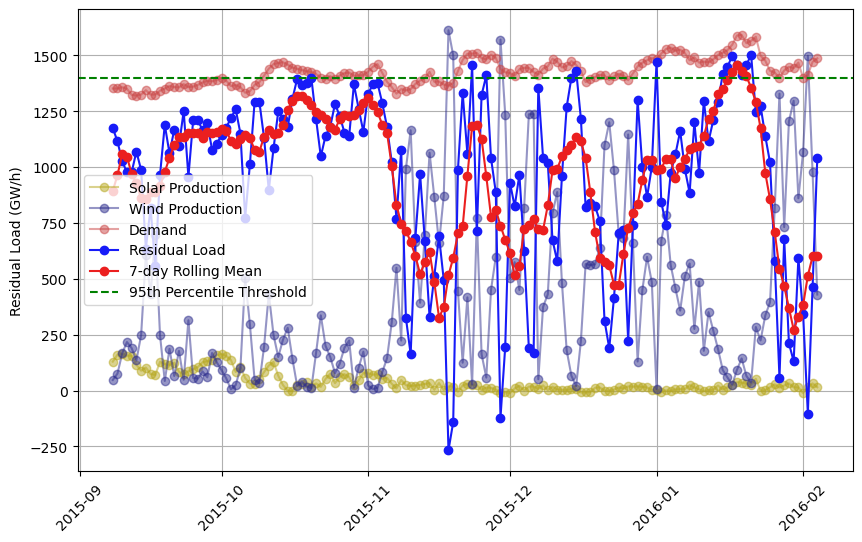

In [13]:
RL = ds_ERA5['Residual_load_adj']
RL_mov_avg_7 = RL.rolling(time=7, center=True).mean()
solar = ds_ERA5['solar_prod_adj']
wind = ds_ERA5['wind_on_prod'] + ds_ERA5['wind_off_prod']
demand = ds_ERA5['demand']

start = 250
box = 150
threshold = np.quantile(RL.values.flatten(), 0.95)

# Extract the data for the specified range
RL_plot = RL.sel(ESM_run='ERA5_hist_week')[start: start+box]
rolling_mean_plot = RL_mov_avg_7.sel(ESM_run='ERA5_hist_week')[start: start+box]
solar = solar.sel(ESM_run='ERA5_hist_week')[start: start+box]
wind = wind.sel(ESM_run='ERA5_hist_week')[start: start+box]
demand = demand.sel(ESM_run='ERA5_hist_week')[start: start+box]



# Plot using matplotlib
plt.figure(figsize=(10, 6))

plt.plot(RL_plot['time'], solar, marker='o', linestyle='-', color="#B6A71E", alpha = 0.5, label='Solar Production')
plt.plot(RL_plot['time'], wind, marker='o', linestyle='-', color="#2D2D8D", alpha = 0.5, label='Wind Production')
plt.plot(RL_plot['time'], demand, marker='o', linestyle='-', color="#CA4747", alpha = 0.5, label='Demand')

plt.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color="#171BF8", label='Residual Load')
plt.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#EB1F1F", label='7-day Rolling Mean')
# Threshold
plt.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')
# plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Residual Load (GW/h)')
# plt.title(f'Residual Load Time Series for run: {LEE["ESM_run"][evt]}')
plt.legend()
plt.grid(True)
plt.show()

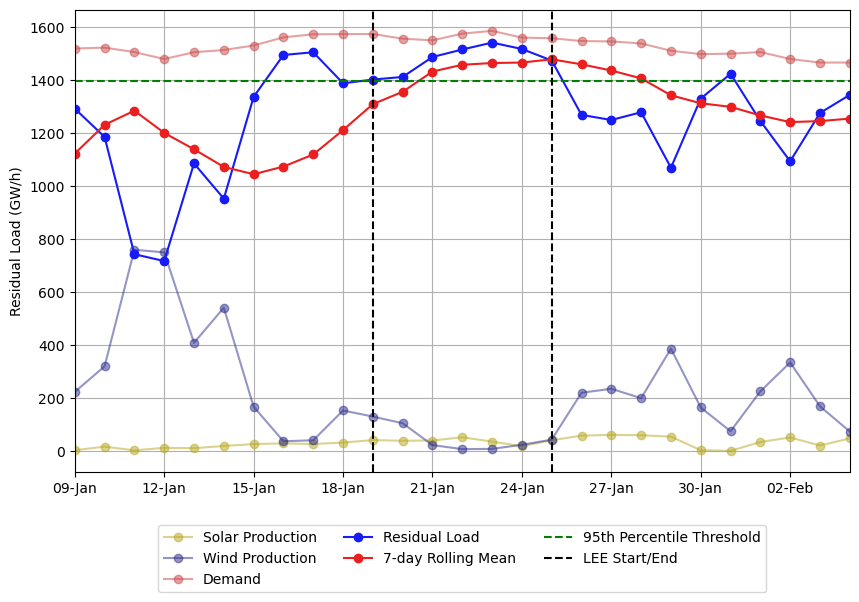

In [14]:
RL = ds_ERA5['Residual_load_adj']
RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
RL_mov_avg_14 = RL.rolling(time=14, center=False).mean()

solar = ds_ERA5['solar_prod_adj']
wind = ds_ERA5['wind_on_prod'] + ds_ERA5['wind_off_prod']
demand = ds_ERA5['demand']

LEE = LEE_7_ERA5
evt = 553
box = 10
threshold = np.quantile(RL.values.flatten(), 0.95)

# Extract the data for the specified range
RL_plot = RL.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
rolling_mean_plot = RL_mov_avg_7.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
rolling_mean_plot_14 = RL_mov_avg_14.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]

solar = solar.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
wind = wind.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
demand = demand.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]



plt.figure(figsize=(10, 6))

plt.plot(RL_plot['time'], solar, marker='o', linestyle='-', color="#B6A71E", alpha=0.5, label='Solar Production')
plt.plot(RL_plot['time'], wind, marker='o', linestyle='-', color="#2D2D8D", alpha=0.5, label='Wind Production')
plt.plot(RL_plot['time'], demand, marker='o', linestyle='-', color="#CA4747", alpha=0.5, label='Demand')

plt.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color="#171BF8", label='Residual Load')
plt.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#EB1F1F", label='7-day Rolling Mean')
# plt.plot(rolling_mean_plot_14['time'], rolling_mean_plot_14, marker='o', linestyle='-', color="#F5A623", label='14-day Rolling Mean')
# Threshold
plt.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')

plt.axvline(x=RL_plot['time'].isel(time=box).values, color='k', linestyle='--', label='LEE Start/End')
plt.axvline(x=RL_plot['time'].isel(time=box+6).values, color='k', linestyle='--')


# Set xticks at regular intervals
xticks = RL_plot['time'][::3]
xtick_labels = [pd.to_datetime(str(t)).strftime('%d-%b') for t in xticks.values]
plt.xticks(xticks, labels=xtick_labels, rotation=0)
plt.xlim(RL_plot['time'].min(), RL_plot['time'].max())
plt.ylabel('Residual Load (GW/h)')
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

# Save plot
# plt.savefig('/home/onennecke/Code/Figures/Event_2017_TS.png', bbox_inches='tight', dpi=300)


plt.show()

In [15]:
RL_plot['time'][box]

<xarray.DataArray 'time' ()> Size: 8B
array('2017-01-19T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    time      datetime64[ns] 8B 2017-01-19
    ESM       <U13 52B 'ERA5_week'
    run       <U10 40B 'hist'
    ESM_run   <U23 92B 'ERA5_hist_week'
    country   float64 8B 9.0
    period    <U4 16B 'week'
    doy       int64 8B 19

In [16]:
LEE_vl_ERA5

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
5149,2015-01-19,2015-01-24,2015-01-19 00:00:00.000000004,18,23,22,6,1497.249011,1465.148179,28.387418,8790.889073,5150,ERA5_week,ERA5_hist_week,2015,19
5150,2015-01-30,2015-01-30,2015-01-30 00:00:00.000000000,29,29,29,1,1412.344556,1412.344556,0.000000,1412.344556,5151,ERA5_week,ERA5_hist_week,2015,30
5151,2015-02-04,2015-02-04,2015-02-04 00:00:00.000000000,34,34,34,1,1449.191276,1449.191276,0.000000,1449.191276,5152,ERA5_week,ERA5_hist_week,2015,35
5152,2015-02-11,2015-02-12,2015-02-11 00:00:00.000000000,41,42,41,2,1424.867738,1423.959088,0.908651,2847.918175,5153,ERA5_week,ERA5_hist_week,2015,42
5153,2015-02-17,2015-02-17,2015-02-17 00:00:00.000000000,47,47,47,1,1422.471565,1422.471565,0.000000,1422.471565,5154,ERA5_week,ERA5_hist_week,2015,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236,2024-11-10,2024-11-10,2024-11-10 00:00:00.000000000,3598,3598,3598,1,1412.311720,1412.311720,0.000000,1412.311720,5237,ERA5_week,ERA5_hist_week,2024,314
5237,2024-11-29,2024-11-29,2024-11-29 00:00:00.000000000,3617,3617,3617,1,1430.343242,1430.343242,0.000000,1430.343242,5238,ERA5_week,ERA5_hist_week,2024,333
5238,2024-12-04,2024-12-04,2024-12-04 00:00:00.000000000,3622,3622,3622,1,1404.000548,1404.000548,0.000000,1404.000548,5239,ERA5_week,ERA5_hist_week,2024,338
5239,2024-12-11,2024-12-13,2024-12-11 00:00:00.000000001,3629,3631,3630,3,1491.259356,1484.232356,7.925435,4452.697068,5240,ERA5_week,ERA5_hist_week,2024,345


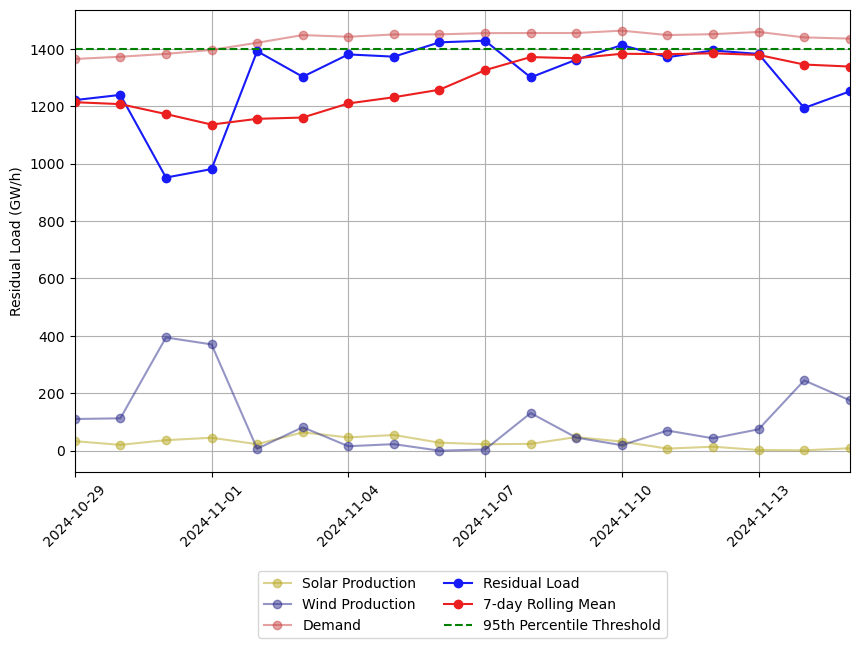

In [17]:
RL = ds_ERA5['Residual_load_adj']
RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
solar = ds_ERA5['solar_prod_adj']
wind = ds_ERA5['wind_on_prod'] + ds_ERA5['wind_off_prod']
demand = ds_ERA5['demand']

LEE = LEE_vl_ERA5
evt = 5235
box = 8
threshold = np.quantile(RL.values.flatten(), 0.95)

# Extract the data for the specified range
RL_plot = RL.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
rolling_mean_plot = RL_mov_avg_7.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
solar = solar.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
wind = wind.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
demand = demand.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]



# Plot using matplotlib
plt.figure(figsize=(10, 6))

plt.plot(RL_plot['time'], solar, marker='o', linestyle='-', color="#B6A71E", alpha=0.5, label='Solar Production')
plt.plot(RL_plot['time'], wind, marker='o', linestyle='-', color="#2D2D8D", alpha=0.5, label='Wind Production')
plt.plot(RL_plot['time'], demand, marker='o', linestyle='-', color="#CA4747", alpha=0.5, label='Demand')

plt.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color="#171BF8", label='Residual Load')
plt.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#EB1F1F", label='7-day Rolling Mean')
# Threshold
plt.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')

# Set xticks at regular intervals
xticks = RL_plot['time'][::3]
plt.xticks(xticks, rotation=45)
plt.xlim(RL_plot['time'].min(), RL_plot['time'].max())
plt.ylabel('Residual Load (GW/h)')
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)

# plt.savefig('/home/onennecke/Code/Figures/Event_2024_TS.png', bbox_inches='tight', dpi=300)

plt.show()

### Plot anomaly maps

In [18]:
def setup_gridlines(ax, deg = 20, alpha = 0.4, ll = True, bl = True, label_size = 14):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [19]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc/'

# files = sorted(glob.glob(os.path.join(path, '*.nc')))
# ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

# ts_datasets


# Open this: ERA5_hist_psl_anomaly.nc
ts_datasets = xr.open_dataset('/climca/people/onennecke/model_output/psl_anomaly/not_bc/ERA5_hist_psl_anomaly.nc')
ts_datasets

<xarray.Dataset> Size: 15MB
Dimensions:   (time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B ...
    gridtype  <U6 24B ...
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
    ESM       <U4 16B ...
    run       <U4 16B ...
    ESM_run   <U9 36B ...
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
Data variables:
    psl       (time, lat, lon) float32 15MB ...
Attributes:
    regrid_method:  bilinear

In [20]:
# Open this: ERA5_hist_wind_anomaly.nc
wind_anom = xr.open_dataset('/climca/people/onennecke/model_output/wind_anomaly/not_bc/ERA5_hist_wind_anomaly.nc')
wind_anom.load()

<xarray.Dataset> Size: 1MB
Dimensions:   (time: 1820, lat: 9, lon: 10)
Coordinates:
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    ESM       <U4 16B 'ERA5'
    run       <U4 16B 'hist'
    ESM_run   <U9 36B 'ERA5_hist'
Data variables:
    sfcWind   (time, lat, lon) float64 1MB -3.432 -3.128 -0.6473 ... 6.515 6.234

In [21]:
# Open this: ERA5_hist_rsds_anomaly.nc
rsds_anom = xr.open_dataset('/climca/people/onennecke/model_output/rsds_anomaly/not_bc/ERA5_hist_rsds_anomaly.nc')
rsds_anom.load()

<xarray.Dataset> Size: 670kB
Dimensions:   (time: 1820, lat: 9, lon: 10)
Coordinates:
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    ESM       <U4 16B 'ERA5'
    run       <U4 16B 'hist'
    ESM_run   <U9 36B 'ERA5_hist'
Data variables:
    rsds      (time, lat, lon) float32 655kB -16.43 -18.55 ... -43.3 -44.28

In [22]:
# Open this: ERA5_hist_tas_anomaly.nc
tas_anom = xr.open_dataset('/climca/people/onennecke/model_output/tas_anomaly/not_bc/ERA5_hist_tas_anomaly.nc')
tas_anom.load()

<xarray.Dataset> Size: 670kB
Dimensions:   (time: 1820, lat: 9, lon: 10)
Coordinates:
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    ESM       <U4 16B 'ERA5'
    run       <U4 16B 'hist'
    ESM_run   <U9 36B 'ERA5_hist'
Data variables:
    tas       (time, lat, lon) float32 655kB -8.511 -8.501 ... -0.6866 -0.3471

### Read Cluster data

In [23]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_data = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
labels = data['labels']
centroids_reshaped = data['centroids_reshaped']

# 1) Unpack sizes & coords
times   = ts_data.time           # (1820,)
runs    = ts_data.ESM_run        # (11,)
# print(times.shape, runs.shape)

# 2) Reshape labels → (time, ESM_run)
labels_da = xr.DataArray(
    labels.reshape(len(runs), len(times)),
    dims    = ("ESM_run", "time"),
    coords  = {"ESM_run": runs, "time": times},
    name    = "cluster_id",
)
labels_da

# Select only ERA5 data
labels_ERA5 = labels_da.sel(ESM_run='ERA5_hist')

In [24]:
LEE_dat_ERA5
LEE_7_ERA5['date_start'].iloc[3]

'2017-01-19'

In [25]:
LEE_7_ERA5

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
550,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000004,18,24,22,7,1497.249011,1449.366519,46.744941,10145.565631,551,ERA5_week,ERA5_hist_week,2015,19
551,2016-01-15,2016-01-21,2016-01-15 00:00:00.000000006,379,385,385,7,1502.737606,1456.367093,32.641307,10194.569654,552,ERA5_week,ERA5_hist_week,2016,15
552,2016-12-14,2016-12-20,2016-12-14 00:00:00.000000003,712,718,715,7,1458.652965,1415.033120,53.764337,9905.231838,553,ERA5_week,ERA5_hist_week,2016,348
553,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000004,748,754,752,7,1541.727728,1478.688488,49.626313,10350.819414,554,ERA5_week,ERA5_hist_week,2017,19
554,2019-01-19,2019-01-25,2019-01-19 00:00:00.000000005,1478,1484,1483,7,1542.347000,1450.622709,86.209183,10154.358961,555,ERA5_week,ERA5_hist_week,2019,19
555,2020-11-26,2020-12-02,2020-11-26 00:00:00.000000006,2154,2160,2160,7,1470.258197,1424.666513,40.762916,9972.665588,556,ERA5_week,ERA5_hist_week,2020,330
556,2022-12-10,2022-12-16,2022-12-10 00:00:00.000000006,2898,2904,2904,7,1554.145256,1492.080803,26.066980,10444.565622,557,ERA5_week,ERA5_hist_week,2022,344
557,2023-01-20,2023-01-26,2023-01-20 00:00:00.000000000,2939,2945,2939,7,1502.508759,1411.341731,74.062268,9879.392118,558,ERA5_week,ERA5_hist_week,2023,20
558,2023-01-22,2023-01-28,2023-01-22 00:00:00.000000006,2941,2947,2947,7,1460.861030,1418.133334,51.195259,9926.933336,559,ERA5_week,ERA5_hist_week,2023,22
559,2023-11-27,2023-12-03,2023-11-27 00:00:00.000000005,3250,3256,3255,7,1540.015423,1450.126204,77.766638,10150.883425,560,ERA5_week,ERA5_hist_week,2023,331


/tmp/ipykernel_1307464/57255314.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


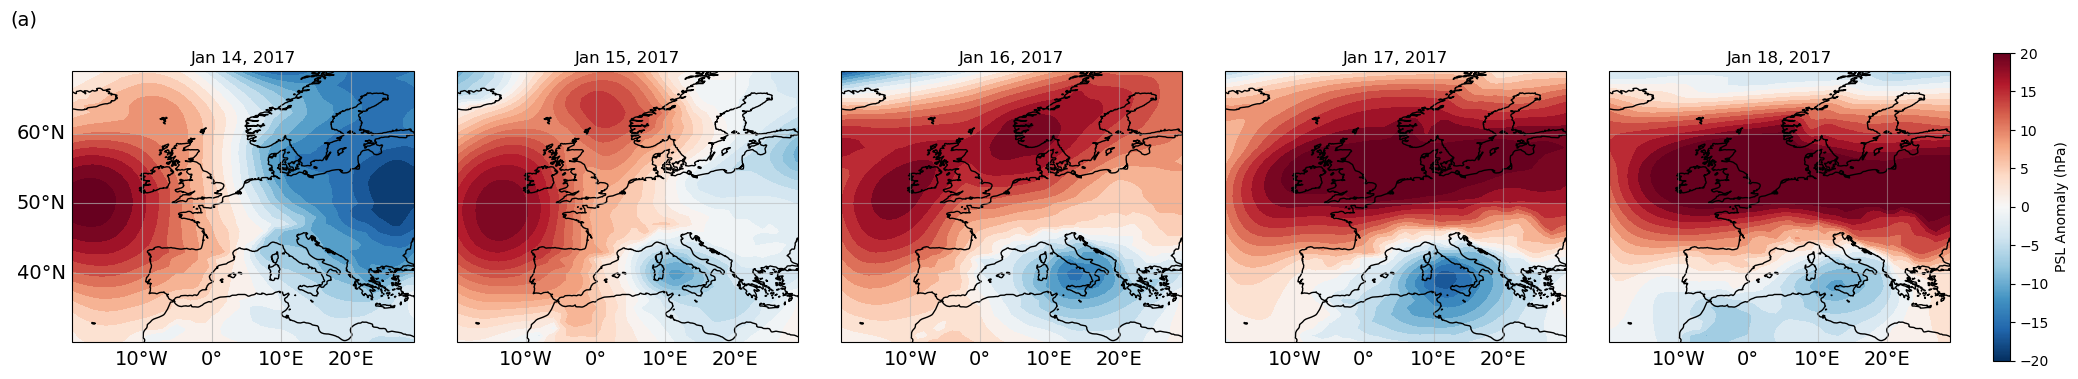

In [26]:

target_date = pd.to_datetime(LEE_7_ERA5['date_start'].iloc[3])
n_days = 5
dates_to_plot = [target_date - pd.Timedelta(days=d) for d in range(n_days, 0, -1)]
# print("dates_to_plot =", dates_to_plot)

cmap_name = "RdBu_r"

# --- select slices from xarray Dataset/DataArray (assumes ts_datasets is an xarray dataset) ---
psl_sel = ts_datasets['psl'].sel(time=dates_to_plot, method='nearest')  # returns DataArray

# convert to numpy and detect units (Pa vs hPa). If values are large (>2000) assume Pa -> divide by 100
psl_slices_hpa = psl_sel.values / 100  # shape expected (ntime, nlat, nlon)

# --- prepare lon/lat grids ---
lon_vals = ((ts_datasets['lon'].values + 180) % 360) - 180
lat_vals = ts_datasets['lat'].values
# ensure ordering of lat/lon matches psl array (psl likely lat x lon)
# print("lon shape", lon_vals.shape, "lat shape", lat_vals.shape)
Lon2d, Lat2d = np.meshgrid(lon_vals, lat_vals)  # Lon2d,Lat2d shapes: (nlat, nlon)

# --- plotting ---
ncols = psl_slices_hpa.shape[0]  # number of times (should be n_days)
nrows = 1
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.15)

vmin = np.nanmin(psl_slices_hpa)
vmax = -vmin

cmap_used = None
for i in range(ncols):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
    z = psl_slices_hpa[i, :, :]  

    cf = ax.contourf(
        Lon2d, Lat2d, z,
        levels=21, vmin=vmin, vmax=vmax,
        cmap=cmap_name, transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()

    setup_gridlines(ax, deg=10, alpha=0.7 if i==0 else 0.5, ll=(i==0))

    title_time = dates_to_plot[i]

    ax.set_title(pd.to_datetime(title_time).strftime("%b %d, %Y"), fontsize=12)

# (a) label
fig.text(0.1, 0.95, "(a)", fontsize=14)

# colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save plot
# plt.savefig('/home/onennecke/Code/Figures/Event_2017_PSL.png', bbox_inches='tight', dpi=300)

plt.show()


/tmp/ipykernel_1307464/1956316261.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


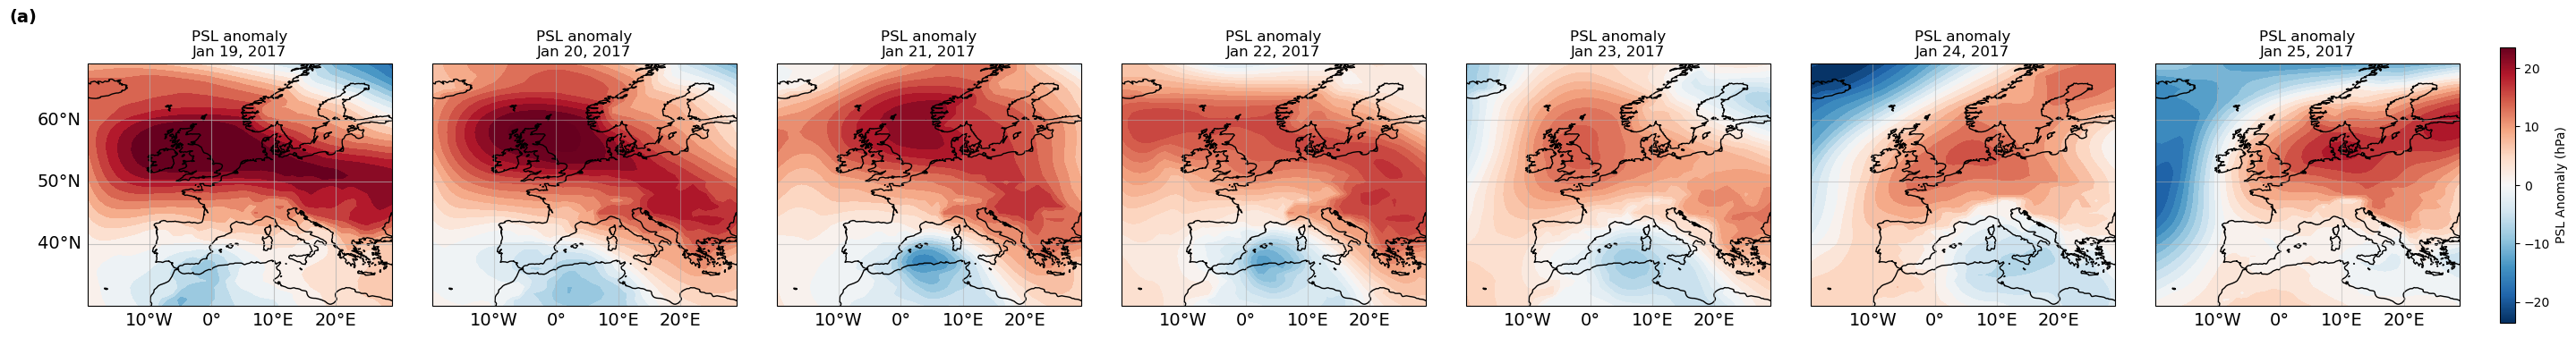

In [27]:
# --- choose target and 7-day window (includes target_date) ---
target_date = pd.to_datetime(LEE_7_ERA5['date_start'].iloc[3])
n_days = 7
dates_to_plot = pd.date_range(start=target_date, periods=n_days).tolist()
# print("dates_to_plot =", dates_to_plot)

cmap_name = "RdBu_r"

# --- select slices from xarray Dataset/DataArray (assumes ts_datasets is an xarray dataset) ---
psl_sel = ts_datasets['psl'].sel(time=dates_to_plot, method='nearest')  # returns DataArray

# convert to numpy and detect units (Pa vs hPa). If values are large (>2000) assume Pa -> divide by 100
psl_slices_hpa = psl_sel.values / 100  # shape expected (ntime, nlat, nlon)

# --- prepare lon/lat grids ---
lon_vals = ((ts_datasets['lon'].values + 180) % 360) - 180
lat_vals = ts_datasets['lat'].values
Lon2d, Lat2d = np.meshgrid(lon_vals, lat_vals)  # Lon2d,Lat2d shapes: (nlat, nlon)

# --- plotting ---
ncols = psl_slices_hpa.shape[0]  # should now be 7
nrows = 1
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.15)

vmin = np.nanmin(psl_slices_hpa)
vmax = -vmin

cmap_used = None
for i in range(ncols):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
    z = psl_slices_hpa[i, :, :]

    cf = ax.contourf(
        Lon2d, Lat2d, z,
        levels=21, vmin=vmin, vmax=vmax,
        cmap=cmap_name, transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()

    setup_gridlines(ax, deg=10, alpha=0.7 if i==0 else 0.5, ll=(i==0))

    title_time = dates_to_plot[i]
    ax.set_title(pd.to_datetime(title_time).strftime("PSL anomaly\n%b %d, %Y"), fontsize=12)

# (a) label
fig.text(0.1, 0.95, "(a)", fontsize=14, fontweight='bold')

# colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [28]:
LEE_vl_ERA5[80:90]
LEE_dat_ERA5[172:173]
# evt = 5235
LEE_dat_ERA5['date_start'].iloc[172]

'2024-11-06'

In [29]:
dates_to_plot

[Timestamp('2017-01-19 00:00:00'),
 Timestamp('2017-01-20 00:00:00'),
 Timestamp('2017-01-21 00:00:00'),
 Timestamp('2017-01-22 00:00:00'),
 Timestamp('2017-01-23 00:00:00'),
 Timestamp('2017-01-24 00:00:00'),
 Timestamp('2017-01-25 00:00:00')]

In [30]:
[target_date - pd.Timedelta(days=d) for d in range(n_days-2, -2, -1)]

[Timestamp('2017-01-14 00:00:00'),
 Timestamp('2017-01-15 00:00:00'),
 Timestamp('2017-01-16 00:00:00'),
 Timestamp('2017-01-17 00:00:00'),
 Timestamp('2017-01-18 00:00:00'),
 Timestamp('2017-01-19 00:00:00'),
 Timestamp('2017-01-20 00:00:00')]

/tmp/ipykernel_1307464/688482563.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


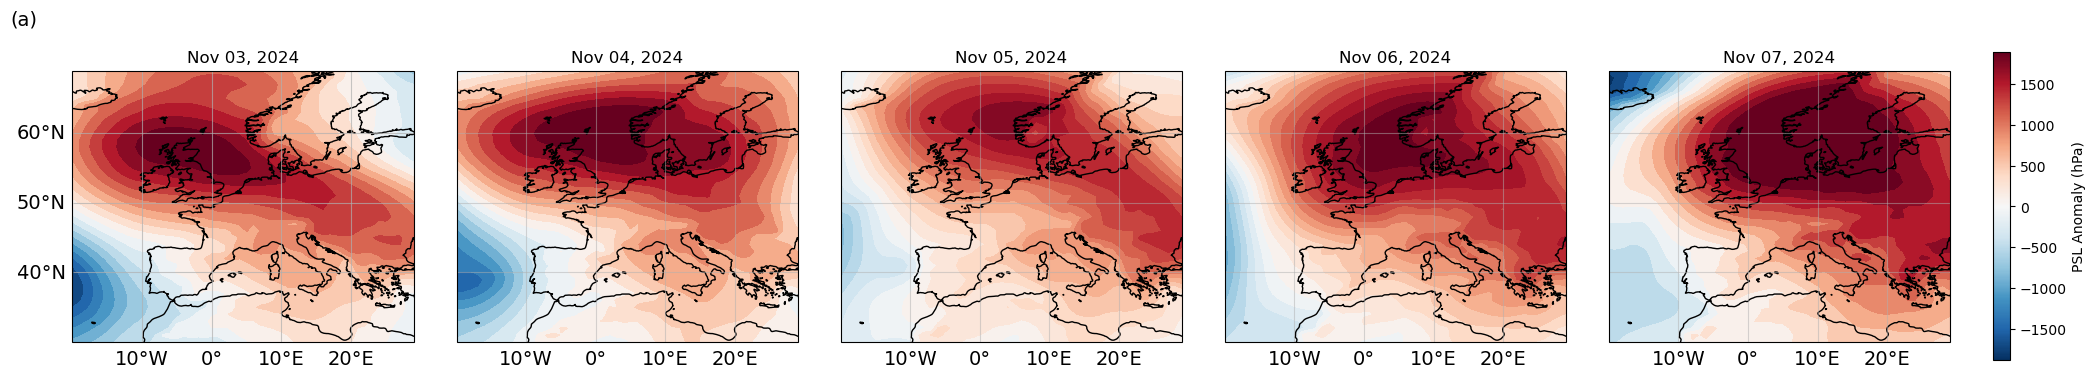

In [31]:

target_date = pd.to_datetime(LEE_dat_ERA5['date_start'].iloc[172])
n_days = 5
dates_to_plot = [target_date - pd.Timedelta(days=d) for d in range(n_days-2, -2, -1)]
# print("dates_to_plot =", dates_to_plot)

cmap_name = "RdBu_r"

# --- select slices from xarray Dataset/DataArray (assumes ts_datasets is an xarray dataset) ---
psl_sel = ts_datasets['psl'].sel(time=dates_to_plot, method='nearest')  # returns DataArray

# convert to numpy and detect units (Pa vs hPa). If values are large (>2000) assume Pa -> divide by 100
psl_slices_hpa = psl_sel.values  # shape expected (ntime, nlat, nlon)

# --- prepare lon/lat grids ---
lon_vals = ((ts_datasets['lon'].values + 180) % 360) - 180
lat_vals = ts_datasets['lat'].values
# ensure ordering of lat/lon matches psl array (psl likely lat x lon)
# print("lon shape", lon_vals.shape, "lat shape", lat_vals.shape)
Lon2d, Lat2d = np.meshgrid(lon_vals, lat_vals)  # Lon2d,Lat2d shapes: (nlat, nlon)

# --- plotting ---
ncols = psl_slices_hpa.shape[0]  # number of times (should be n_days)
nrows = 1
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.15)

vmin = np.nanmin(psl_slices_hpa)
vmax = -vmin

cmap_used = None
for i in range(ncols):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
    z = psl_slices_hpa[i, :, :]  

    cf = ax.contourf(
        Lon2d, Lat2d, z,
        levels=21, vmin=vmin, vmax=vmax,
        cmap=cmap_name, transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()

    setup_gridlines(ax, deg=10, alpha=0.7 if i==0 else 0.5, ll=(i==0))

    title_time = dates_to_plot[i]

    ax.set_title(pd.to_datetime(title_time).strftime("%b %d, %Y"), fontsize=12)

# (a) label
fig.text(0.1, 0.95, "(a)", fontsize=14)

# colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Make one pretty plot

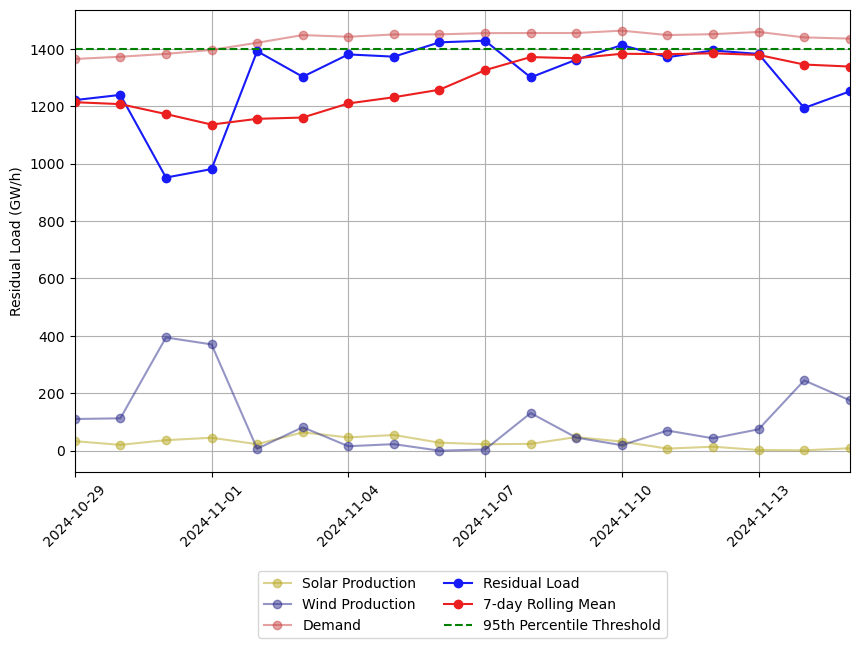

In [32]:
RL = ds_ERA5['Residual_load_adj']
RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
solar = ds_ERA5['solar_prod_adj']
wind = ds_ERA5['wind_on_prod'] + ds_ERA5['wind_off_prod']
demand = ds_ERA5['demand']

LEE = LEE_vl_ERA5
evt = 5235
box = 8
threshold = np.quantile(RL.values.flatten(), 0.95)

# Extract the data for the specified range
RL_plot = RL.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
rolling_mean_plot = RL_mov_avg_7.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
solar = solar.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
wind = wind.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
demand = demand.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]



# Plot using matplotlib
plt.figure(figsize=(10, 6))

plt.plot(RL_plot['time'], solar, marker='o', linestyle='-', color="#B6A71E", alpha=0.5, label='Solar Production')
plt.plot(RL_plot['time'], wind, marker='o', linestyle='-', color="#2D2D8D", alpha=0.5, label='Wind Production')
plt.plot(RL_plot['time'], demand, marker='o', linestyle='-', color="#CA4747", alpha=0.5, label='Demand')

plt.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color="#171BF8", label='Residual Load')
plt.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#EB1F1F", label='7-day Rolling Mean')
# Threshold
plt.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')

# Set xticks at regular intervals
xticks = RL_plot['time'][::3]
plt.xticks(xticks, rotation=45)
plt.xlim(RL_plot['time'].min(), RL_plot['time'].max())
plt.ylabel('Residual Load (GW/h)')
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)

# plt.savefig('/home/onennecke/Code/Figures/Event_2024_TS.png', bbox_inches='tight', dpi=300)

plt.show()

/tmp/ipykernel_1307464/14684108.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


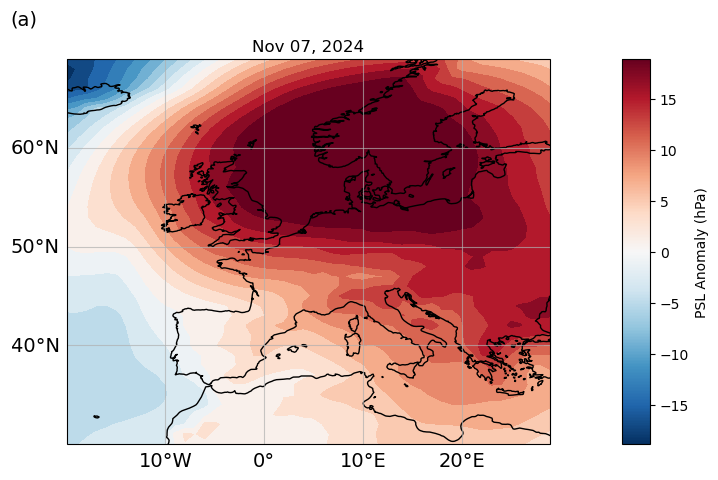

In [33]:


# --- your existing selections ---
target_date = pd.to_datetime(LEE_dat_ERA5['date_start'].iloc[172])
n_days = 5
dates_to_plot = [target_date - pd.Timedelta(days=d) for d in range(n_days-2, -2, -1)]

cmap_name = "RdBu_r"

psl_sel = ts_datasets['psl'].sel(time=dates_to_plot, method='nearest')
psl_slices = psl_sel.values  # (ntime, nlat, nlon)

# convert Pa -> hPa if necessary (optional but recommended)
if np.nanmax(psl_slices) > 2000:
    psl_slices = psl_slices / 100.0

lon_vals = ((ts_datasets['lon'].values + 180) % 360) - 180
lat_vals = ts_datasets['lat'].values
Lon2d, Lat2d = np.meshgrid(lon_vals, lat_vals)

# --- prepare single-plot figure for the LAST time slice ---
last_idx = -1
z = psl_slices[last_idx, :, :]

# use vmin/vmax computed over all slices to stay consistent with previous multi-panel
vmin = np.nanmin(psl_slices)
vmax = -vmin

fig = plt.figure(figsize=(8, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 0.05], wspace=0.12)

ax = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
cf = ax.contourf(
    Lon2d, Lat2d, z,
    levels=21, vmin=vmin, vmax=vmax,
    cmap=cmap_name, transform=ccrs.PlateCarree()
)
ax.coastlines()

# keep your gridline helper (ll True for leftmost)
setup_gridlines(ax, deg=10, alpha=0.7, ll=True)

title_time = dates_to_plot[last_idx]
ax.set_title(pd.to_datetime(title_time).strftime("%b %d, %Y"), fontsize=12)

# colorbar on the right
cax = fig.add_subplot(gs[0, 1])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cf.cmap)
sm.set_array([])  # required for colorbar
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

# optional label (if you want it)
fig.text(0.1, 0.95, "(a)", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [34]:
lon_edges = wind_anom.lon.values
lat_edges = wind_anom.lat.values

def setup_gridlines_small(ax, deg = 2, alpha = 0.4, ll = True, bl = True, label_size = 16):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    # ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    # ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=label_size)
    
    
    
lon_edges_1 = ts_datasets.lon.values
lat_edges_1 = ts_datasets.lat.values

def setup_gridlines_big(ax, deg = 20, alpha = 0.4, ll = True, bl = True, label_size = 16):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.array([-20, 0, 20, 40]) # np.array([340, 360, 0, 20, 40]) # np.arange(lon_edges_1.min(), lon_edges_1.max() + deg, deg)
    yticks = np.arange(lat_edges_1.min() + 1, lat_edges_1.max() + deg, deg)
    # ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    # ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=label_size)

In [35]:
target_date = pd.to_datetime(LEE_dat_ERA5['date_start'].iloc[172])
target_date
n_days = 3
dates_to_plot = [target_date - pd.Timedelta(days=d) for d in range(n_days-1, -1, -1)]
dates_to_plot

[Timestamp('2024-11-04 00:00:00'),
 Timestamp('2024-11-05 00:00:00'),
 Timestamp('2024-11-06 00:00:00')]

In [36]:
# --- Time-series selections (use your existing variables) ---
RL = ds_ERA5['Residual_load_adj']
RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
solar = ds_ERA5['solar_prod_adj']
wind = ds_ERA5['wind_on_prod'] + ds_ERA5['wind_off_prod']
demand = ds_ERA5['demand']

LEE = LEE_vl_ERA5
evt = 5235
box = 8
threshold = np.quantile(RL.values.flatten(), 0.95)

RL_plot = RL.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
rolling_mean_plot = RL_mov_avg_7.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
solar_plot = solar.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
wind_plot = wind.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
demand_plot = demand.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]

# Cluster data
labels_ERA5_event = labels_ERA5.sel(time=slice(RL_plot['time'][0].values, RL_plot['time'][-1].values))
labels_ERA5_event

# --- Map 1 (PSL) selections ---
target_date = pd.to_datetime(LEE_dat_ERA5['date_start'].iloc[172])
n_days = 3
dates_to_plot = [target_date - pd.Timedelta(days=d) for d in range(n_days-1, -1, -1)]

cmap_name = "RdBu_r"

psl_sel = ts_datasets['psl'].sel(time=dates_to_plot, method='nearest')
psl_slices = psl_sel.values  # (ntime, nlat, nlon)
psl_slices = psl_slices / 100.0 # convert Pa -> hPa

lon_vals = ((ts_datasets['lon'].values + 180) % 360) - 180
lat_vals = ts_datasets['lat'].values
Lon2d, Lat2d = np.meshgrid(lon_vals, lat_vals)

# --- Map 2 (sfcWind) selections ---
sfcWind_sel = wind_anom['sfcWind'].sel(time=dates_to_plot, method='nearest')
sfcWind_slices = sfcWind_sel.values
lon_g = ((wind_anom['lon'].values + 180) % 360) - 180
lat_g = wind_anom['lat'].values
Lon2d_g, Lat2d_g = np.meshgrid(lon_g, lat_g)
# --- Map 3 (rsds) selections ---
rsds_sel = rsds_anom['rsds'].sel(time=dates_to_plot, method='nearest')
rsds_slices = rsds_sel.values
# --- Map 4 (tas) selections ---
tas_sel = tas_anom['tas'].sel(time=dates_to_plot, method='nearest')
tas_slices = tas_sel.values

# --- Prepare symmetric vmin/vmax per variable (over selected times) ---
def symmetric_vmin_vmax(arr):
    mn = np.nanmin(arr)
    mx = np.nanmax(arr)
    m = max(abs(mn), abs(mx))
    return -m, m

psl_vmin, psl_vmax = symmetric_vmin_vmax(psl_slices)
sfc_vmin, sfc_vmax = symmetric_vmin_vmax(sfcWind_slices)
rsds_vmin, rsds_vmax = symmetric_vmin_vmax(rsds_slices)
tas_vmin, tas_vmax = symmetric_vmin_vmax(tas_slices)

# choose last time-slice for display (as you requested)
last_idx = -1
psl_z = psl_slices[last_idx, :, :]
sfc_z = sfcWind_slices[last_idx, :, :]
rsds_z = rsds_slices[last_idx, :, :]
tas_z = tas_slices[last_idx, :, :]


In [37]:
### Find out how extreme the values during the event are compared to the full dataset

RL_value_at_event= RL.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]]
rolling_mean_value_at_event= RL_mov_avg_7.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]]
solar_value_at_event= solar.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]]
wind_value_at_event= wind.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]]
demand_value_at_event= demand.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]]

# # Calculate percentiles
from scipy import stats

RL_all = RL.values.flatten()
RL_event_percentiles = stats.percentileofscore(RL_all, RL_value_at_event, kind='rank')
solar_event_percentiles = stats.percentileofscore(solar.values.flatten(), solar_value_at_event, kind='rank')
wind_event_percentiles = stats.percentileofscore(wind.values.flatten(), wind_value_at_event, kind='rank')
demand_event_percentiles = stats.percentileofscore(demand.values.flatten(), demand_value_at_event, kind='rank')

# Calculate percentiles for the extended winter season (ONDJFM)
RL_ondjfm = RL.sel(time=RL['time.month'].isin([10, 11, 12, 1, 2, 3])).values.flatten()
solar_ondjfm = solar.sel(time=solar['time.month'].isin([10, 11, 12, 1, 2, 3])).values.flatten()
wind_ondjfm = wind.sel(time=wind['time.month'].isin([10, 11, 12, 1, 2, 3])).values.flatten()
demand_ondjfm = demand.sel(time=demand['time.month'].isin([10, 11, 12, 1, 2, 3])).values.flatten()

RL_event_percentiles_ondjfm = stats.percentileofscore(RL_ondjfm, RL_value_at_event, kind='rank')
solar_event_percentiles_ondjfm = stats.percentileofscore(solar_ondjfm, solar_value_at_event, kind='rank')
wind_event_percentiles_ondjfm = stats.percentileofscore(wind_ondjfm, wind_value_at_event, kind='rank')
demand_event_percentiles_ondjfm = stats.percentileofscore(demand_ondjfm, demand_value_at_event, kind='rank')

# Print percentiles
print(f"Residual Load at event {RL_value_at_event.values:.2f}, winter percentile: {RL_event_percentiles_ondjfm:.2f}%, total percentile: {RL_event_percentiles:.2f}%")
print(f"Solar Production at event {solar_value_at_event.values:.2f}, winter percentile: {solar_event_percentiles_ondjfm:.2f}%, total percentile: {solar_event_percentiles:.2f}%")
print(f"Wind Production at event {wind_value_at_event.values:.2f}, winter percentile: {wind_event_percentiles_ondjfm:.2f}%, total percentile: {wind_event_percentiles:.2f}%")
print(f"Demand at event {demand_value_at_event.values:.2f}, winter percentile: {demand_event_percentiles_ondjfm:.2f}%, total percentile: {demand_event_percentiles:.2f}%")

Residual Load at event 1422.10, winter percentile: 92.31%, total percentile: 96.16%
Solar Production at event 27.79, winter percentile: 47.14%, total percentile: 23.53%
Wind Production at event 0.00, winter percentile: 0.05%, total percentile: 0.05%
Demand at event 1449.89, winter percentile: 46.65%, total percentile: 71.78%


In [38]:
RL_ondjfm = RL.sel(time=RL['time.month'].isin([10, 11, 12, 1, 2, 3])).values.flatten()
RL_ondjfm

array([ 777.52873511,   96.93869171,  535.2921622 , ..., 1119.69708764,
        687.53477784,  671.44513227])

In [39]:
# Convert to pandas Series (assumes time dimension exists)
wind_series = wind.to_series()
# Get 10 smallest values
lowest_wind_values = wind_series.nsmallest(10)
for date, value in zip(lowest_wind_values.index, lowest_wind_values.values):
    print(f"Date: {date}, Wind Production: {value}")
    
# Convert to pandas Series (assumes time dimension exists)
RL_series = RL.to_series()
# Get 10 largest values
lowest_RL_values = RL_series.nlargest(50)
for date, value in zip(lowest_RL_values.index, lowest_RL_values.values):
    print(f"Date: {date}, RL: {value}")
    


Date: ('ERA5_hist_week', Timestamp('2015-08-02 00:00:00')), Wind Production: 0.0
Date: ('ERA5_hist_week', Timestamp('2016-06-16 00:00:00')), Wind Production: 0.0
Date: ('ERA5_hist_week', Timestamp('2024-11-06 00:00:00')), Wind Production: 0.0
Date: ('ERA5_hist_week', Timestamp('2020-07-19 00:00:00')), Wind Production: 0.04220280448720203
Date: ('ERA5_hist_week', Timestamp('2015-07-05 00:00:00')), Wind Production: 0.07686754623448352
Date: ('ERA5_hist_week', Timestamp('2017-08-26 00:00:00')), Wind Production: 0.09435698827311353
Date: ('ERA5_hist_week', Timestamp('2022-05-31 00:00:00')), Wind Production: 0.12336302139005471
Date: ('ERA5_hist_week', Timestamp('2024-06-18 00:00:00')), Wind Production: 0.2003672458713583
Date: ('ERA5_hist_week', Timestamp('2023-06-17 00:00:00')), Wind Production: 0.3567412408879753
Date: ('ERA5_hist_week', Timestamp('2022-05-04 00:00:00')), Wind Production: 0.36154866134349783
Date: ('ERA5_hist_week', Timestamp('2022-12-16 00:00:00')), RL: 1554.14525574449

In [35]:
# mpl.rcParams.update({
#     'font.size': 16,
#     'axes.titlesize': 18,
#     'axes.labelsize': 16,
#     'xtick.labelsize': 14,
#     'ytick.labelsize': 14,
#     'legend.fontsize': 16,
#     'figure.titlesize': 18,
# })

# # --- Figure layout: big TS on left, 4 stacked maps on right ---
# fig = plt.figure(figsize=(16, 10))
# outer_gs = GridSpec(1, 2, width_ratios=[2.6, 1.0], wspace=0.18)

# # Left: time series
# ax_ts = fig.add_subplot(outer_gs[0, 0])
# ax_ts.plot(RL_plot['time'], solar_plot, marker='o', linestyle='-', color="#B6A71E", alpha=0.6, label='Solar Production')
# ax_ts.plot(RL_plot['time'], wind_plot, marker='o', linestyle='-', color="#2D2D8D", alpha=0.6, label='Wind Production')
# ax_ts.plot(RL_plot['time'], demand_plot, marker='o', linestyle='-', color="#CA4747", alpha=0.6, label='Demand')

# ax_ts.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color="#171BF8", label='Residual Load')
# ax_ts.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#EB1F1F", label='7-day Rolling Mean')

# ax_ts.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')

# xticks = RL_plot['time'][::3]
# ax_ts.set_xticks(xticks)
# # ax_ts.set_xticklabels([pd.to_datetime(t).strftime('%Y-%m-%d') for t in xticks], rotation=45, ha='right')
# ax_ts.set_xlim(RL_plot['time'].min(), RL_plot['time'].max())
# ax_ts.set_ylabel('Residual Load (GW/h)')
# ax_ts.grid(True)
# ax_ts.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=True)
# ax_ts.set_title(pd.to_datetime(dates_to_plot[last_idx]).strftime("VRES on the %b %d, %Y"))

# # Right: 4 stacked maps; allocate small first map
# map_gs = GridSpecFromSubplotSpec(4, 2, subplot_spec=outer_gs[0, 1],
#                                  height_ratios=[1.0, 1.0, 1.0, 1.0], width_ratios=[1.0, 0.12],
#                                  hspace=0.28, wspace=0.05)

# # Map 1: PSL
# ax0 = fig.add_subplot(map_gs[0, 0], projection=ccrs.PlateCarree())
# cf0 = ax0.contourf(Lon2d, Lat2d, psl_z, levels=21, vmin=psl_vmin, vmax=psl_vmax,
#                    cmap=cmap_name, transform=ccrs.PlateCarree())
# ax0.coastlines()
# setup_gridlines_big(ax0, deg=10, alpha=0.7, ll=True)  # uses your helper
# # ax0.set_title(pd.to_datetime(dates_to_plot[last_idx]).strftime("PSL %b %d, %Y"), fontsize=10)
# cax0 = fig.add_subplot(map_gs[0, 1])
# sm0 = ScalarMappable(norm=plt.Normalize(vmin=psl_vmin, vmax=psl_vmax), cmap=cf0.cmap)
# sm0.set_array([])
# plt.colorbar(sm0, cax=cax0, label='PSL anomaly (hPa)')

# # Map 2: sfcWind
# ax1 = fig.add_subplot(map_gs[1, 0], projection=ccrs.PlateCarree())
# cf1 = ax1.pcolormesh(Lon2d_g, Lat2d_g, sfc_z, vmin=sfc_vmin, vmax=sfc_vmax,
#                      cmap=cmap_name, transform=ccrs.PlateCarree())
# ax1.coastlines()
# ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
# # smaller gridlines function for maps with less clutter
# setup_gridlines_small(ax1, alpha=0.7, ll=True, bl=False)
# # ax1.set_title(pd.to_datetime(dates_to_plot[last_idx]).strftime("sfcWind %b %d, %Y"), fontsize=10)
# cax1 = fig.add_subplot(map_gs[1, 1])
# sm1 = ScalarMappable(norm=plt.Normalize(vmin=sfc_vmin, vmax=sfc_vmax), cmap=cf1.cmap)
# sm1.set_array([])
# plt.colorbar(sm1, cax=cax1, label='Wind speed anomaly (m/s)')

# # Map 3: rsds
# ax2 = fig.add_subplot(map_gs[2, 0], projection=ccrs.PlateCarree())
# cf2 = ax2.pcolormesh(Lon2d_g, Lat2d_g, rsds_z, vmin=rsds_vmin, vmax=rsds_vmax,
#                      cmap=cmap_name, transform=ccrs.PlateCarree())
# ax2.coastlines()
# ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

# setup_gridlines_small(ax2, alpha=0.7, ll=True, bl=False)
# # ax2.set_title(pd.to_datetime(dates_to_plot[last_idx]).strftime("rsds %b %d, %Y"), fontsize=10)
# cax2 = fig.add_subplot(map_gs[2, 1])
# sm2 = ScalarMappable(norm=plt.Normalize(vmin=rsds_vmin, vmax=rsds_vmax), cmap=cf2.cmap)
# sm2.set_array([])
# plt.colorbar(sm2, cax=cax2, label='RSDS anomaly (W/m²)')

# # Map 4: tas
# ax3 = fig.add_subplot(map_gs[3, 0], projection=ccrs.PlateCarree())
# cf3 = ax3.pcolormesh(Lon2d_g, Lat2d_g, tas_z, vmin=tas_vmin, vmax=tas_vmax,
#                      cmap=cmap_name, transform=ccrs.PlateCarree())
# ax3.coastlines()
# ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
# setup_gridlines_small(ax3, alpha=0.7, ll=True)
# # ax3.set_title(pd.to_datetime(dates_to_plot[last_idx]).strftime("tas %b %d, %Y"), fontsize=10)
# cax3 = fig.add_subplot(map_gs[3, 1])
# sm3 = ScalarMappable(norm=plt.Normalize(vmin=tas_vmin, vmax=tas_vmax), cmap=cf3.cmap)
# sm3.set_array([])
# plt.colorbar(sm3, cax=cax3, label='Tas anomaly (K)')

# # final tweaks
# plt.tight_layout(rect=[0, 0, 1, 0.96])
# # fig.suptitle(f"Event {evt}: Time series + maps (maps show last date: {pd.to_datetime(dates_to_plot[last_idx]).strftime('%Y-%m-%d')})",
# #              fontsize=14)
# plt.show()


In [40]:
LEE_dat_ERA5[172:175]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
9668,2024-11-06,2024-11-06,2024-11-06,3594,3594,3594,1,1422.102507,1422.102507,0.0,1422.102507,9669,ERA5_week,ERA5_hist_week,2024,310
9669,2024-11-07,2024-11-07,2024-11-07,3595,3595,3595,1,1427.796599,1427.796599,0.0,1427.796599,9670,ERA5_week,ERA5_hist_week,2024,311
9670,2024-11-10,2024-11-10,2024-11-10,3598,3598,3598,1,1412.311720,1412.311720,0.0,1412.311720,9671,ERA5_week,ERA5_hist_week,2024,314


In [41]:
target_date

Timestamp('2024-11-06 00:00:00')

In [42]:
target_date = pd.to_datetime(LEE_dat_ERA5['date_start'].iloc[172])
target_date

Timestamp('2024-11-06 00:00:00')

In [43]:
dates_to_plot = [target_date - pd.Timedelta(days=d) for d in range(3-1, -1, -1)]
dates_to_plot

[Timestamp('2024-11-04 00:00:00'),
 Timestamp('2024-11-05 00:00:00'),
 Timestamp('2024-11-06 00:00:00')]

In [44]:
# choose last time-slice for display (as you requested)
last_idx = -1
psl_z = psl_slices[last_idx, :, :]
sfc_z = sfcWind_slices[last_idx, :, :]
rsds_z = rsds_slices[last_idx, :, :]
tas_z = tas_slices[last_idx, :, :]

In [45]:
labels_ERA5_event

<xarray.DataArray 'cluster_id' (time: 18)> Size: 72B
array([4, 4, 3, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3], dtype=int32)
Coordinates:
    ESM_run  <U23 92B 'ERA5_hist'
  * time     (time) datetime64[ns] 144B 2024-10-29 2024-10-30 ... 2024-11-15

/tmp/ipykernel_1307464/3023530791.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


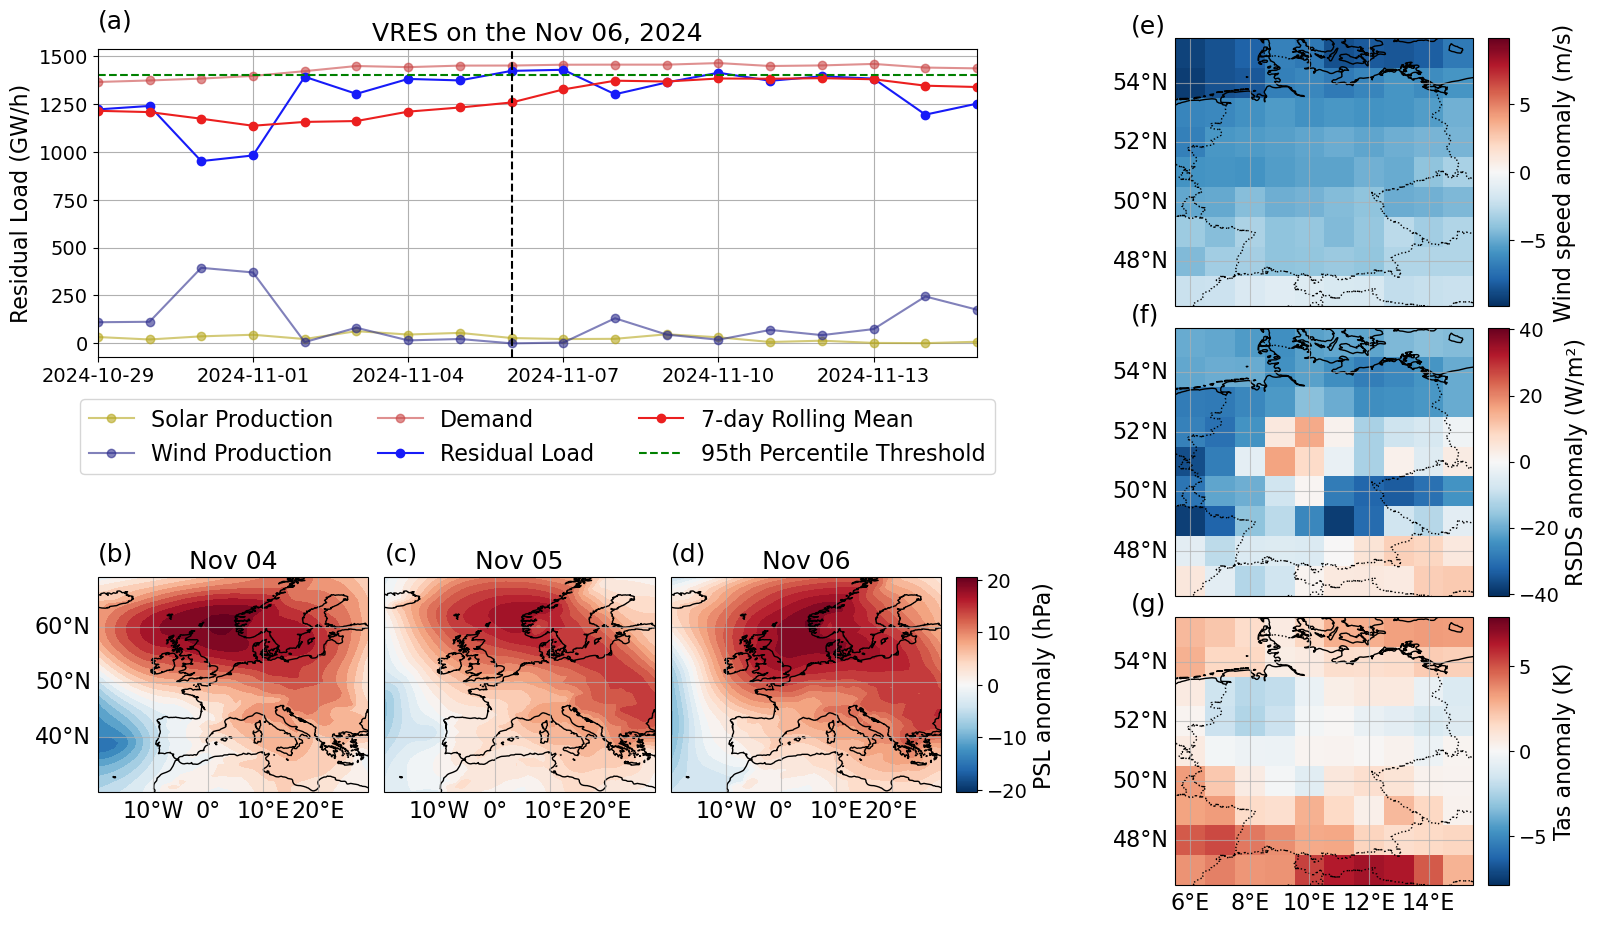

In [46]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

psl_sel = ts_datasets['psl'].sel(time=dates_to_plot, method='nearest')
psl_slices = psl_sel.values  # (ntime, nlat, nlon)

# convert Pa -> hPa if necessary (optional but recommended)
if np.nanmax(psl_slices) > 2000:
    psl_slices = psl_slices / 100.0



fig = plt.figure(figsize=(18, 11))
outer_gs = GridSpec(2, 2, width_ratios=[2.6, 1.0],
                    height_ratios=[0.48, 0.52], hspace=0.20, wspace=0.3)

# --- Bottom-left: PSL row first (so we can measure its combined width) ---
psl_row_gs = GridSpecFromSubplotSpec(1, 4, subplot_spec=outer_gs[1, 0],
                                     width_ratios=[1.0, 1.0, 1.0, 0.06],
                                     wspace=0.08, hspace=0.0)

psl_axes = []
cfp = None
for i in range(3):
    axp = fig.add_subplot(psl_row_gs[0, i], projection=ccrs.PlateCarree())
    cfp = axp.contourf(Lon2d, Lat2d, psl_slices[i, :, :], levels=21,
                       vmin=psl_vmin, vmax=psl_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
    axp.coastlines()
    setup_gridlines_big(axp, deg=10, alpha=0.7, ll=(i == 0))
    axp.set_title(pd.to_datetime(dates_to_plot[i]).strftime("%b %d"))  # uses rcParams titlesize
    psl_axes.append(axp)

# compute bounding box that covers the three PSL axes (NOT including the small cbar column)
pos = [ax.get_position() for ax in psl_axes]
x0 = min(p.x0 for p in pos)
y0 = min(p.y0 for p in pos)
x1 = max(p.x1 for p in pos)
y1 = max(p.y1 for p in pos)

# create a narrow axes to the right of the PSL row to use as a single PSL colorbar
# give a tiny gap so cbar doesn't touch the maps
cax_psl = fig.add_axes([x1 + 0.008, y0, 0.012, y1 - y0])
cbar_psl = plt.colorbar(ScalarMappable(norm=Normalize(vmin=psl_vmin, vmax=psl_vmax),
                                       cmap=cfp.cmap), cax=cax_psl)
# use rcParams sizes for ticks/label
cbar_psl.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar_psl.set_label('PSL anomaly (hPa)', fontsize=mpl.rcParams['axes.labelsize'])

# --- Right column: 3 stacked maps (use GridSpec so vertical spacing is good) ---
map_gs = GridSpecFromSubplotSpec(3, 1, subplot_spec=outer_gs[:, 1],
                                 height_ratios=[1.0, 1.0, 1.0], hspace=0.08)

# Map 1: sfcWind (top)
ax1 = fig.add_subplot(map_gs[0, 0], projection=ccrs.PlateCarree())
cf1 = ax1.pcolormesh(Lon2d_g, Lat2d_g, sfc_z, vmin=sfc_vmin, vmax=sfc_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
setup_gridlines_small(ax1, alpha=0.7, ll=True, bl=False)

# create cax from ax1 position (works reliably with Cartopy)
pos1 = ax1.get_position()
cax1 = fig.add_axes([pos1.x1 + 0.008, pos1.y0, 0.012, pos1.height])
cbar1 = plt.colorbar(ScalarMappable(norm=Normalize(vmin=sfc_vmin, vmax=sfc_vmax), cmap=cf1.cmap), cax=cax1)
cbar1.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar1.set_label('Wind speed anomaly (m/s)', fontsize=mpl.rcParams['axes.labelsize'])


# Map 2: rsds (middle)
ax2 = fig.add_subplot(map_gs[1, 0], projection=ccrs.PlateCarree())
cf2 = ax2.pcolormesh(Lon2d_g, Lat2d_g, rsds_z, vmin=rsds_vmin, vmax=rsds_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
setup_gridlines_small(ax2, alpha=0.7, ll=True, bl=False)

pos2 = ax2.get_position()
cax2 = fig.add_axes([pos2.x1 + 0.008, pos2.y0, 0.012, pos2.height])
cbar2 = plt.colorbar(ScalarMappable(norm=Normalize(vmin=rsds_vmin, vmax=rsds_vmax), cmap=cf2.cmap), cax=cax2)
cbar2.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar2.set_label('RSDS anomaly (W/m²)', fontsize=mpl.rcParams['axes.labelsize'])


# Map 3: tas (bottom)
ax3 = fig.add_subplot(map_gs[2, 0], projection=ccrs.PlateCarree())
cf3 = ax3.pcolormesh(Lon2d_g, Lat2d_g, tas_z, vmin=tas_vmin, vmax=tas_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
setup_gridlines_small(ax3, alpha=0.7, ll=True)

pos3 = ax3.get_position()
cax3 = fig.add_axes([pos3.x1 + 0.008, pos3.y0, 0.012, pos3.height])
cbar3 = plt.colorbar(ScalarMappable(norm=Normalize(vmin=tas_vmin, vmax=tas_vmax), cmap=cf3.cmap), cax=cax3)
cbar3.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar3.set_label('Tas anomaly (K)', fontsize=mpl.rcParams['axes.labelsize'])


# --- Now place the timeseries axis so its horizontal extent matches the combined PSL maps + PSL colorbar ---
# Create a temporary timeseries axis using the top-left GridSpec slot, then reposition it
ax_ts = fig.add_subplot(outer_gs[0, 0])
# measure original pos to compute top limit
pos_top_area = ax_ts.get_position()

# compute rightmost x using the PSL colorbar axes (so timeseries includes the PSL cbar)
psl_cbar_pos = cax_psl.get_position()
psl_right = psl_cbar_pos.x1  # right edge of PSL maps + their colorbar

# compute new position: fill horizontally from x0 -> psl_right, vertically
# increase the gap under the timeseries so the legend can sit there comfortably
new_x = x0
new_width = psl_right - x0

# make the vertical gap much larger (increase the value added to y1)
new_y = y1 + 0.20  # bigger value = more space under the TS
new_height = pos_top_area.y1 - new_y - 0.01  # leave a tiny top margin

ax_ts.set_position([new_x, new_y, new_width, new_height])

# Plot timeseries content on ax_ts (same as before)
ax_ts.plot(RL_plot['time'], solar_plot, marker='o', linestyle='-', color="#B6A71E", alpha=0.6, label='Solar Production')
ax_ts.plot(RL_plot['time'], wind_plot, marker='o', linestyle='-', color="#2D2D8D", alpha=0.6, label='Wind Production')
ax_ts.plot(RL_plot['time'], demand_plot, marker='o', linestyle='-', color="#CA4747", alpha=0.6, label='Demand')
ax_ts.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color="#171BF8", label='Residual Load')
ax_ts.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#EB1F1F", label='7-day Rolling Mean')
ax_ts.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')

event_time = pd.to_datetime(RL_plot['time'].isel(time=box).values)
ax_ts.axvline(x=event_time, color='k', linestyle='--', linewidth=1.5)

xticks = RL_plot['time'][::3]
ax_ts.set_xticks(xticks)
ax_ts.set_xlim(RL_plot['time'].min(), RL_plot['time'].max())
ax_ts.set_ylabel('Residual Load (GW/h)')
ax_ts.grid(True)

# move legend farther down into the added gap so it no longer overlaps the PSL maps
leg = ax_ts.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=3, frameon=True)
for text in leg.get_texts():
    text.set_fontsize(mpl.rcParams['legend.fontsize'])

ax_ts.set_title(pd.to_datetime(dates_to_plot[last_idx]).strftime("VRES on the %b %d, %Y"))

# ---------------------------------------------------------------------
# Add subplot letters (a) - (g)
# order: (a) timeseries, (b)-(d) PSL maps left->right, (e)-(g) right-column maps top->bottom
label_kwargs = dict(transform=None, fontsize=18, fontweight='bold', va='bottom', ha='left')

# helper to add a label in axis coordinates
def add_subplot_label(ax, label, x=-0.0, y=1.05):
    # use ax.transAxes so the label is placed relative to the axes
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=18, va='bottom', ha='left')

# (a)
add_subplot_label(ax_ts, '(a)')

# (b)-(d) PSL maps
add_subplot_label(psl_axes[0], '(b)')
add_subplot_label(psl_axes[1], '(c)')
add_subplot_label(psl_axes[2], '(d)')

# (e)-(g) right column
add_subplot_label(ax1, '(e)', x=-0.15, y=1)
add_subplot_label(ax2, '(f)', x=-0.15, y=1)
add_subplot_label(ax3, '(g)', x=-0.15, y=1)

# Final layout adjustments
plt.tight_layout()

# Save figure
# plt.savefig('/home/onennecke/Code/Figures/Specific_event_06_11.png', bbox_inches='tight', dpi=300)

plt.show()


/tmp/ipykernel_1307464/2987561851.py:272: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


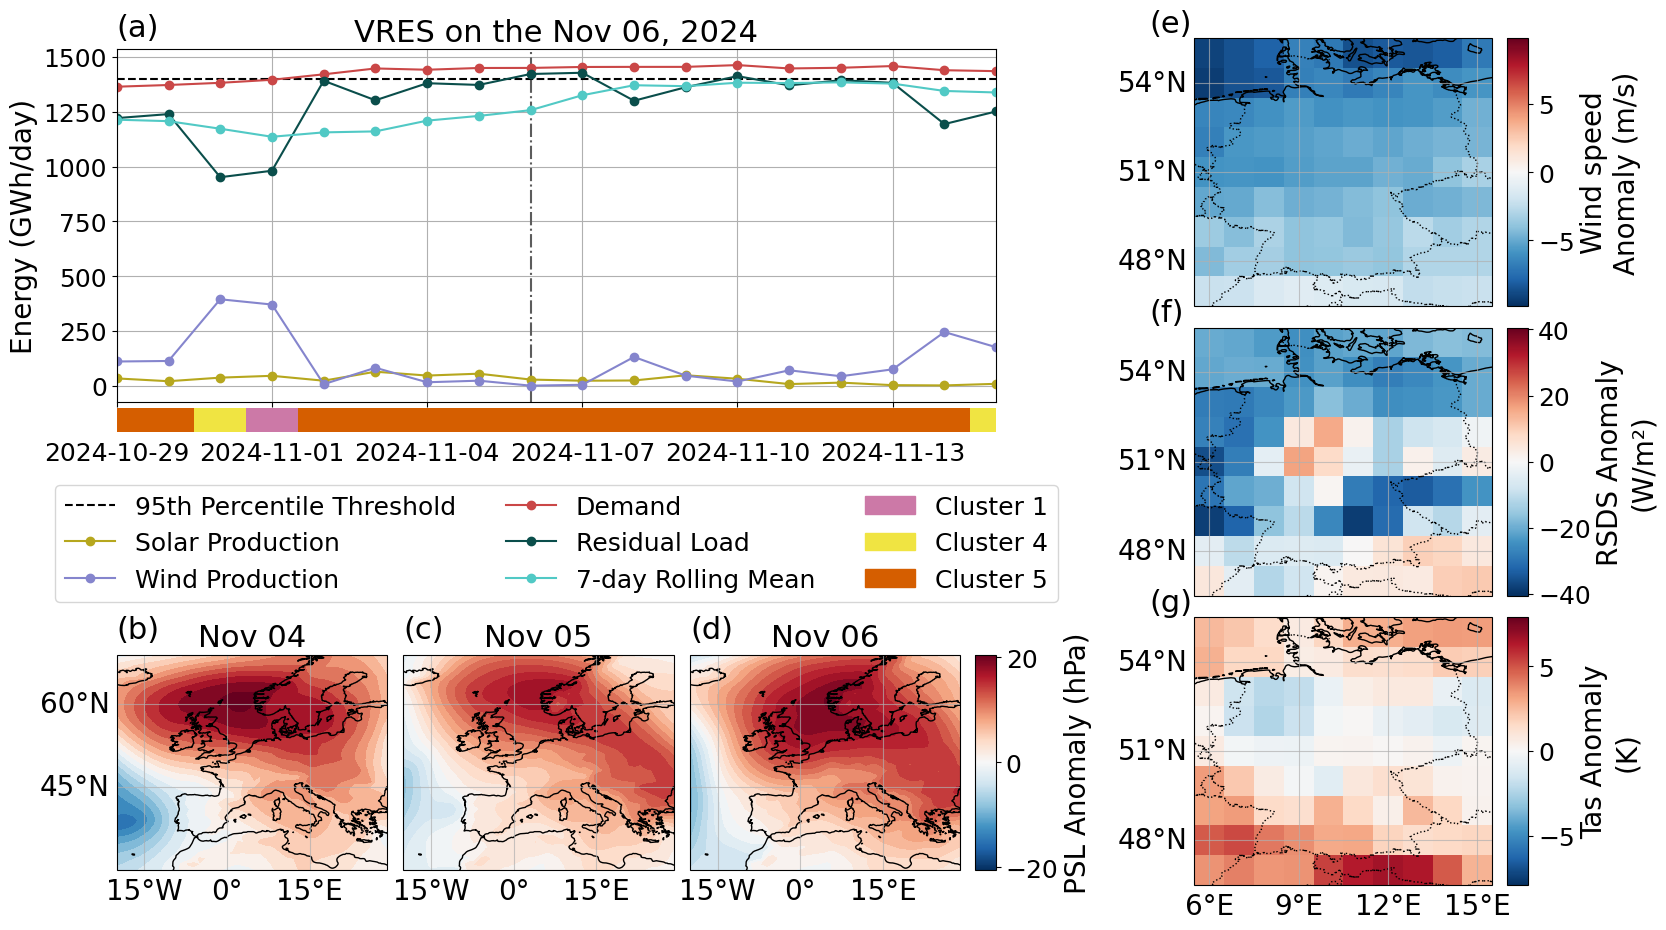

In [ ]:
mpl.rcParams.update({
    'font.size': 16+4,
    'axes.titlesize': 18+4,
    'axes.labelsize': 16+4,
    'xtick.labelsize': 14+4,
    'ytick.labelsize': 14+4,
    'legend.fontsize': 16+2,
    'figure.titlesize': 18+4,
})

psl_sel = ts_datasets['psl'].sel(time=dates_to_plot, method='nearest')
psl_slices = psl_sel.values  # (ntime, nlat, nlon)

# convert Pa -> hPa if necessary
psl_slices = psl_slices / 100.0


fig = plt.figure(figsize=(18, 11))

outer_gs = GridSpec(3, 2,
                    width_ratios=[2.6, 1.0],
                    # top: timeseries area, middle: spacer, bottom: PSL/maps area
                    height_ratios=[0.1, 0.9, 0.49],
                    hspace=0.20, wspace=0.3)

# --- Bottom-left: PSL row first (so we can measure its combined width) ---
psl_row_gs = GridSpecFromSubplotSpec(1, 4, subplot_spec=outer_gs[2, 0],
                                     width_ratios=[1.0, 1.0, 1.0, 0.06],
                                     wspace=0.08, hspace=0.0)

psl_axes = []
cfp = None
for i in range(3):
    axp = fig.add_subplot(psl_row_gs[0, i], projection=ccrs.PlateCarree())
    cfp = axp.contourf(Lon2d, Lat2d, psl_slices[i, :, :], levels=21,
                       vmin=psl_vmin, vmax=psl_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
    axp.coastlines()
    setup_gridlines_big(axp, deg=15, label_size = 20, alpha =0.7, ll=(i == 0))
    axp.set_title(pd.to_datetime(dates_to_plot[i]).strftime("%b %d"))  # uses rcParams titlesize
    psl_axes.append(axp)

# compute bounding box that covers the three PSL axes (NOT including the small cbar column)
pos = [ax.get_position() for ax in psl_axes]
x0 = min(p.x0 for p in pos)
y0 = min(p.y0 for p in pos)
x1 = max(p.x1 for p in pos)
y1 = max(p.y1 for p in pos)

# create a narrow axes to the right of the PSL row to use as a single PSL colorbar
# give a tiny gap so cbar doesn't touch the maps
cax_psl = fig.add_axes([x1 + 0.008, y0, 0.012, y1 - y0])
cbar_psl = plt.colorbar(ScalarMappable(norm=Normalize(vmin=psl_vmin, vmax=psl_vmax),
                                       cmap=cfp.cmap), cax=cax_psl)
# use rcParams sizes for ticks/label
cbar_psl.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar_psl.set_label('PSL Anomaly (hPa)', fontsize=mpl.rcParams['axes.labelsize'])

# --- Right column: 3 stacked maps (use GridSpec so vertical spacing is good) ---
map_gs = GridSpecFromSubplotSpec(3, 1, subplot_spec=outer_gs[:, 1],
                                 height_ratios=[1.0, 1.0, 1.0], hspace=0.08)

# Map 1: sfcWind (top)
ax1 = fig.add_subplot(map_gs[0, 0], projection=ccrs.PlateCarree())
cf1 = ax1.pcolormesh(Lon2d_g, Lat2d_g, sfc_z, vmin=sfc_vmin, vmax=sfc_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
setup_gridlines_small(ax1, deg = 3, label_size = 20, alpha=0.7, ll=True, bl=False)

# create cax from ax1 position (works reliably with Cartopy)
pos1 = ax1.get_position()
cax1 = fig.add_axes([pos1.x1 + 0.008, pos1.y0, 0.012, pos1.height])
cbar1 = plt.colorbar(ScalarMappable(norm=Normalize(vmin=sfc_vmin, vmax=sfc_vmax), cmap=cf1.cmap), cax=cax1)
cbar1.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar1.set_label('Wind speed\nAnomaly (m/s)', fontsize=mpl.rcParams['axes.labelsize'])


# Map 2: rsds (middle)
ax2 = fig.add_subplot(map_gs[1, 0], projection=ccrs.PlateCarree())
cf2 = ax2.pcolormesh(Lon2d_g, Lat2d_g, rsds_z, vmin=rsds_vmin, vmax=rsds_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
setup_gridlines_small(ax2, deg = 3, label_size = 20, alpha=0.7, ll=True, bl=False)

pos2 = ax2.get_position()
cax2 = fig.add_axes([pos2.x1 + 0.008, pos2.y0, 0.012, pos2.height])
cbar2 = plt.colorbar(ScalarMappable(norm=Normalize(vmin=rsds_vmin, vmax=rsds_vmax), cmap=cf2.cmap), cax=cax2)
cbar2.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar2.set_label('RSDS Anomaly\n(W/m²)', fontsize=mpl.rcParams['axes.labelsize'])


# Map 3: tas (bottom)
ax3 = fig.add_subplot(map_gs[2, 0], projection=ccrs.PlateCarree())
cf3 = ax3.pcolormesh(Lon2d_g, Lat2d_g, tas_z, vmin=tas_vmin, vmax=tas_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
setup_gridlines_small(ax3, deg = 3, label_size = 20, alpha=0.7, ll=True)

pos3 = ax3.get_position()
cax3 = fig.add_axes([pos3.x1 + 0.008, pos3.y0, 0.012, pos3.height])
cbar3 = plt.colorbar(ScalarMappable(norm=Normalize(vmin=tas_vmin, vmax=tas_vmax), cmap=cf3.cmap), cax=cax3)
cbar3.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar3.set_label('Tas Anomaly\n(K)', fontsize=mpl.rcParams['axes.labelsize'])


# --- Now place the timeseries axis so its horizontal extent matches the combined PSL maps + PSL colorbar ---
# Create a temporary timeseries axis using the top-left GridSpec slot, then reposition it
ax_ts = fig.add_subplot(outer_gs[0, 0])
# measure original pos to compute top limit
pos_top_area = ax_ts.get_position()

# compute rightmost x using the PSL colorbar axes (so timeseries includes the PSL cbar)
psl_cbar_pos = cax_psl.get_position()
psl_right = psl_cbar_pos.x1  # right edge of PSL maps + their colorbar

# compute new position: fill horizontally from x0 -> psl_right, vertically
# increase the gap under the timeseries so the legend can sit there comfortably
new_x = x0
new_width = psl_right - x0

# make the vertical gap much larger (increase the value added to y1)
new_y = y1 + 0.23  # bigger value = more space under the TS
new_height = pos_top_area.y1 - new_y - 0.01  # leave a tiny top margin

ax_ts.set_position([new_x, new_y, new_width, new_height])

event_time = pd.to_datetime(RL_plot['time'].isel(time=box).values)
ax_ts.axvline(x=event_time, color="#5C5C5C", linestyle='-.', linewidth=1.5)
ax_ts.axhline(y=threshold, color='#000000', linestyle='--', label='95th Percentile Threshold')


# Plot timeseries content on ax_ts (same as before)
ax_ts.plot(RL_plot['time'], solar_plot, marker='o', linestyle='-', color="#B6A71E", alpha=1, label='Solar Production')
ax_ts.plot(RL_plot['time'], wind_plot, marker='o', linestyle='-', color="#8585CD", alpha=1, label='Wind Production')
ax_ts.plot(RL_plot['time'], demand_plot, marker='o', linestyle='-', color="#CA4747", alpha=1, label='Demand')
ax_ts.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color="#0A4E4B", label='Residual Load')
ax_ts.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#51C9C5", label='7-day Rolling Mean')

# ax_ts.plot(RL_plot['time'], solar_plot, marker='o', linestyle='-', color="#C9A71A", alpha=1, label='Solar Production')
# ax_ts.plot(RL_plot['time'], wind_plot,  marker='o', linestyle='-', color="#6F67C9", alpha=1, label='Wind Production')
# ax_ts.plot(RL_plot['time'], demand_plot, marker='o', linestyle='-', color="#B83B3B", alpha=1, label='Demand')
# ax_ts.plot(RL_plot['time'], RL_plot,     marker='o', linestyle='-', color="#0E7A72", alpha=1, label='Residual Load')
# ax_ts.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#349F99", alpha=1, label='7-day Rolling Mean')


xticks = RL_plot['time'][::3]
ax_ts.set_xticks(xticks)
ax_ts.tick_params(axis='x', pad =25)
ax_ts.set_xlim(RL_plot['time'].min(), RL_plot['time'].max())
ax_ts.set_ylabel('Energy (GWh/day)')
ax_ts.grid(True)

# move legend farther down into the added gap so it no longer overlaps the PSL maps
# leg = ax_ts.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=3, frameon=True)
# for text in leg.get_texts():
#     text.set_fontsize(mpl.rcParams['legend.fontsize'])
# ax_ts.add_artist(leg)
# --- Inserted: add cluster-colored day bar + x-axis labels + cluster legend (FIXED) ---

# user-specified cluster colors (for clusters 0..4)
# cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]

# extract cluster times / ids from the xarray DataArray
cluster_times = pd.to_datetime(labels_ERA5_event['time'].values)
cluster_ids_raw = np.array(labels_ERA5_event.values).ravel().astype(float)  # allow NaN

# times from RL_plot
ts_times = pd.to_datetime(RL_plot['time'].values)

# Try to align cluster_ids to ts_times
cluster_for_ts = np.full(len(ts_times), np.nan)

# 1) exact match by timestamp
for i, ct in enumerate(cluster_times):
    matches = np.where(ts_times == ct)[0]
    cluster_for_ts[matches[0]] = cluster_ids_raw[i]

# prepare plotting coordinates in Matplotlib datenum space
ts_num = mdates.date2num(ts_times)
half_width = 0.5

# get ax_ts position to place strip and xlabels beneath it
pos_ts = ax_ts.get_position()
strip_height = 0.022  # height of colored day bar
gap_between = 0.006    # gap between axes
label_height = 0.05    # height for x-axis labels

# compute y positions
strip_y = pos_ts.y0 - gap_between - strip_height
labels_y = strip_y - gap_between - label_height

# create the color strip axes
ax_strip = fig.add_axes([pos_ts.x0, strip_y, pos_ts.width, strip_height], sharex=ax_ts)
ax_strip.set_ylim(0, 1)
ax_strip.axis('off')

# draw colored rectangles for each time step
for i, cid in enumerate(cluster_for_ts):
    if np.isnan(cid):
        continue
    cid = int(cid)
    if cid < 0 or cid > 4:
        continue
    color = cluster_colors[cid]
    left = ts_num[i] - half_width
    right = ts_num[i] + half_width
    # draw a solid horizontal rectangle (no transform argument)
    ax_strip.fill_betweenx([0, 1], left, right, facecolor=color, edgecolor=None, linewidth=0)

# --- Add cluster legend beneath the existing timeseries legend ---
present_ids = [int(c) for c in np.unique(cluster_for_ts[~np.isnan(cluster_for_ts)])]
present_ids = [c for c in sorted(present_ids) if 0 <= c <= 4]

# --- Combined legend: lines (timeseries) + cluster patches ---
# get existing line handles & labels from ax_ts (these are the timeseries/axhline)
line_handles, line_labels = ax_ts.get_legend_handles_labels()

# build cluster handles in the order present_ids (skip if none)
cluster_handles = []
cluster_labels = []
for c in present_ids:
    cluster_handles.append(Patch(color=cluster_colors[c], label=f'Cluster {c+1}'))
    cluster_labels.append(f'Cluster {c+1}')

# combine handles and labels (lines first, clusters after)
all_handles = line_handles + cluster_handles
all_labels = line_labels + cluster_labels

# choose location / layout; adjust ncol as you prefer
ncol_total = min(len(all_handles), 3)  # tweak to taste
ax_ts.legend(all_handles, all_labels, loc='upper center', bbox_to_anchor=(0.5, -0.2),
             ncol=ncol_total, frameon=True)

# ensure legend text size matches rcParams
leg = ax_ts.get_legend()
for text in leg.get_texts():
    text.set_fontsize(mpl.rcParams['legend.fontsize'])
# --- end combined legend ---


ax_ts.set_title(pd.to_datetime(dates_to_plot[last_idx]).strftime("VRES on the %b %d, %Y"))

# ---------------------------------------------------------------------
# Add subplot letters (a) - (g)
# order: (a) timeseries, (b)-(d) PSL maps left->right, (e)-(g) right-column maps top->bottom
label_kwargs = dict(transform=None, fontsize=18, fontweight='bold', va='bottom', ha='left')

# helper to add a label in axis coordinates
def add_subplot_label(ax, label, x=-0.0, y=1.05):
    # use ax.transAxes so the label is placed relative to the axes
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=22, va='bottom', ha='left')

# (a)
add_subplot_label(ax_ts, '(a)', y=1.02)
# (b)-(d) PSL maps
add_subplot_label(psl_axes[0], '(b)')
add_subplot_label(psl_axes[1], '(c)')
add_subplot_label(psl_axes[2], '(d)')
# (e)-(g) right column
add_subplot_label(ax1, '(e)', x=-0.15, y=1)
add_subplot_label(ax2, '(f)', x=-0.15, y=1)
add_subplot_label(ax3, '(g)', x=-0.15, y=1)

# Final layout adjustments
plt.tight_layout()

# Save figure
# plt.savefig('/home/onennecke/Code/Figures/Specific_event_06_11.png', bbox_inches='tight', dpi=300)

plt.show()


/tmp/ipykernel_3094502/2329364057.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


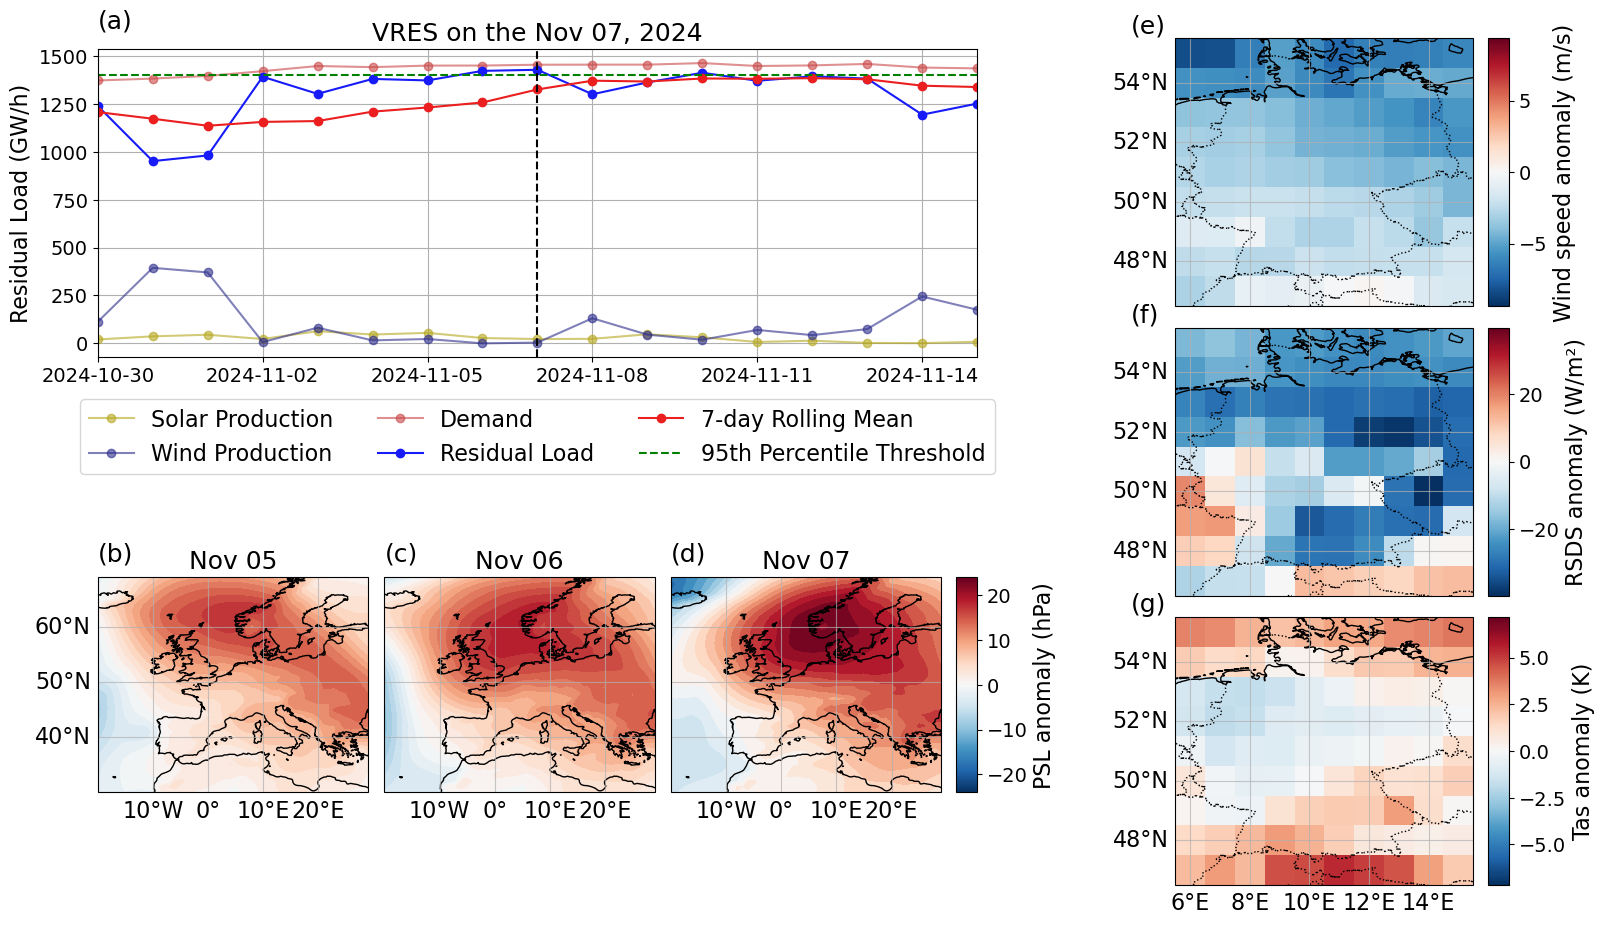

In [ ]:
fig = plt.figure(figsize=(18, 11))
outer_gs = GridSpec(2, 2, width_ratios=[2.6, 1.0],
                    height_ratios=[0.48, 0.52], hspace=0.20, wspace=0.3)

# --- Bottom-left: PSL row first (so we can measure its combined width) ---
psl_row_gs = GridSpecFromSubplotSpec(1, 4, subplot_spec=outer_gs[1, 0],
                                     width_ratios=[1.0, 1.0, 1.0, 0.06],
                                     wspace=0.08, hspace=0.0)

psl_axes = []
cfp = None
for i in range(3):
    axp = fig.add_subplot(psl_row_gs[0, i], projection=ccrs.PlateCarree())
    cfp = axp.contourf(Lon2d, Lat2d, psl_slices[i, :, :], levels=21,
                       vmin=psl_vmin, vmax=psl_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
    axp.coastlines()
    setup_gridlines_big(axp, deg=10, alpha=0.7, ll=(i == 0))
    axp.set_title(pd.to_datetime(dates_to_plot[i]).strftime("%b %d"))  # uses rcParams titlesize
    psl_axes.append(axp)

# compute bounding box that covers the three PSL axes (NOT including the small cbar column)
pos = [ax.get_position() for ax in psl_axes]
x0 = min(p.x0 for p in pos)
y0 = min(p.y0 for p in pos)
x1 = max(p.x1 for p in pos)
y1 = max(p.y1 for p in pos)

# create a narrow axes to the right of the PSL row to use as a single PSL colorbar
# give a tiny gap so cbar doesn't touch the maps
cax_psl = fig.add_axes([x1 + 0.008, y0, 0.012, y1 - y0])
cbar_psl = plt.colorbar(ScalarMappable(norm=Normalize(vmin=psl_vmin, vmax=psl_vmax),
                                       cmap=cfp.cmap), cax=cax_psl)
# use rcParams sizes for ticks/label
cbar_psl.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar_psl.set_label('PSL anomaly (hPa)', fontsize=mpl.rcParams['axes.labelsize'])

# --- Right column: 3 stacked maps (use GridSpec so vertical spacing is good) ---
map_gs = GridSpecFromSubplotSpec(3, 1, subplot_spec=outer_gs[:, 1],
                                 height_ratios=[1.0, 1.0, 1.0], hspace=0.08)

# Map 1: sfcWind (top)
ax1 = fig.add_subplot(map_gs[0, 0], projection=ccrs.PlateCarree())
cf1 = ax1.pcolormesh(Lon2d_g, Lat2d_g, sfc_z, vmin=sfc_vmin, vmax=sfc_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
setup_gridlines_small(ax1, alpha=0.7, ll=True, bl=False)

# create cax from ax1 position (works reliably with Cartopy)
pos1 = ax1.get_position()
cax1 = fig.add_axes([pos1.x1 + 0.008, pos1.y0, 0.012, pos1.height])
cbar1 = plt.colorbar(ScalarMappable(norm=Normalize(vmin=sfc_vmin, vmax=sfc_vmax), cmap=cf1.cmap), cax=cax1)
cbar1.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar1.set_label('Wind speed anomaly (m/s)', fontsize=mpl.rcParams['axes.labelsize'])


# Map 2: rsds (middle)
ax2 = fig.add_subplot(map_gs[1, 0], projection=ccrs.PlateCarree())
cf2 = ax2.pcolormesh(Lon2d_g, Lat2d_g, rsds_z, vmin=rsds_vmin, vmax=rsds_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
setup_gridlines_small(ax2, alpha=0.7, ll=True, bl=False)

pos2 = ax2.get_position()
cax2 = fig.add_axes([pos2.x1 + 0.008, pos2.y0, 0.012, pos2.height])
cbar2 = plt.colorbar(ScalarMappable(norm=Normalize(vmin=rsds_vmin, vmax=rsds_vmax), cmap=cf2.cmap), cax=cax2)
cbar2.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar2.set_label('RSDS anomaly (W/m²)', fontsize=mpl.rcParams['axes.labelsize'])


# Map 3: tas (bottom)
ax3 = fig.add_subplot(map_gs[2, 0], projection=ccrs.PlateCarree())
cf3 = ax3.pcolormesh(Lon2d_g, Lat2d_g, tas_z, vmin=tas_vmin, vmax=tas_vmax, cmap=cmap_name, transform=ccrs.PlateCarree())
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
setup_gridlines_small(ax3, alpha=0.7, ll=True)

pos3 = ax3.get_position()
cax3 = fig.add_axes([pos3.x1 + 0.008, pos3.y0, 0.012, pos3.height])
cbar3 = plt.colorbar(ScalarMappable(norm=Normalize(vmin=tas_vmin, vmax=tas_vmax), cmap=cf3.cmap), cax=cax3)
cbar3.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'])
cbar3.set_label('Tas anomaly (K)', fontsize=mpl.rcParams['axes.labelsize'])


# --- Now place the timeseries axis so its horizontal extent matches the combined PSL maps + PSL colorbar ---
# Create a temporary timeseries axis using the top-left GridSpec slot, then reposition it
ax_ts = fig.add_subplot(outer_gs[0, 0])
# measure original pos to compute top limit
pos_top_area = ax_ts.get_position()

# compute rightmost x using the PSL colorbar axes (so timeseries includes the PSL cbar)
psl_cbar_pos = cax_psl.get_position()
psl_right = psl_cbar_pos.x1  # right edge of PSL maps + their colorbar

# compute new position: fill horizontally from x0 -> psl_right, vertically
# increase the gap under the timeseries so the legend can sit there comfortably
new_x = x0
new_width = psl_right - x0

# make the vertical gap much larger (increase the value added to y1)
new_y = y1 + 0.20  # bigger value = more space under the TS
new_height = pos_top_area.y1 - new_y - 0.01  # leave a tiny top margin

ax_ts.set_position([new_x, new_y, new_width, new_height])

# Plot timeseries content on ax_ts (same as before)
ax_ts.plot(RL_plot['time'], solar_plot, marker='o', linestyle='-', color="#B6A71E", alpha=0.6, label='Solar Production')
ax_ts.plot(RL_plot['time'], wind_plot, marker='o', linestyle='-', color="#2D2D8D", alpha=0.6, label='Wind Production')
ax_ts.plot(RL_plot['time'], demand_plot, marker='o', linestyle='-', color="#CA4747", alpha=0.6, label='Demand')
ax_ts.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color="#171BF8", label='Residual Load')
ax_ts.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#EB1F1F", label='7-day Rolling Mean')
ax_ts.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')

event_time = pd.to_datetime(RL_plot['time'].isel(time=box).values)
ax_ts.axvline(x=event_time, color='k', linestyle='--', linewidth=1.5)

xticks = RL_plot['time'][::3]
ax_ts.set_xticks(xticks)
ax_ts.set_xlim(RL_plot['time'].min(), RL_plot['time'].max())
ax_ts.set_ylabel('Residual Load (GW/h)')
ax_ts.grid(True)

# move legend farther down into the added gap so it no longer overlaps the PSL maps
leg = ax_ts.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=3, frameon=True)
for text in leg.get_texts():
    text.set_fontsize(mpl.rcParams['legend.fontsize'])

ax_ts.set_title(pd.to_datetime(dates_to_plot[last_idx]).strftime("VRES on the %b %d, %Y"))

# ---------------------------------------------------------------------
# Add subplot letters (a) - (g)
# order: (a) timeseries, (b)-(d) PSL maps left->right, (e)-(g) right-column maps top->bottom
label_kwargs = dict(transform=None, fontsize=18, fontweight='bold', va='bottom', ha='left')

# helper to add a label in axis coordinates
def add_subplot_label(ax, label, x=-0.0, y=1.05):
    # use ax.transAxes so the label is placed relative to the axes
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=18, va='bottom', ha='left')

# (a)
add_subplot_label(ax_ts, '(a)')

# (b)-(d) PSL maps
add_subplot_label(psl_axes[0], '(b)')
add_subplot_label(psl_axes[1], '(c)')
add_subplot_label(psl_axes[2], '(d)')

# (e)-(g) right column
add_subplot_label(ax1, '(e)', x=-0.15, y=1)
add_subplot_label(ax2, '(f)', x=-0.15, y=1)
add_subplot_label(ax3, '(g)', x=-0.15, y=1)

# Final layout adjustments
plt.tight_layout()

# Save figure
plt.savefig('/home/onennecke/Code/Figures/Specific_event_07_11.png', bbox_inches='tight', dpi=300)

plt.show()
